# Comparación de SHAP y LIME en la Explicabilidad de Modelos QSAR
## Consistencia y Estabilidad de las Explicaciones — Predicción de Toxicidad Molecular

> **Curso:** Fundamentos de Inteligencia Artificial Explicable  
> **Autoras:** Alice Rambo — Fiorella Cravero

---

### Estructura del Notebook
1. Instalación de dependencias
2. Carga y exploración de los datos
3. Entrenamiento de modelos (CV estratificada)
4. Evaluación predictiva sobre conjunto de prueba
5. Selección de mejores modelos
6. Generación de explicaciones: SHAP y LIME
7. Cálculo de métricas de explicabilidad (Rank Consistency & Stability)
8. Análisis comparativo y selección del método preferido
9. Casos de mayor desacuerdo SHAP vs LIME
10. Instabilidad local: ¿dónde falla cada método?
11. Análisis de features "conflictivas"

## 1. Instalación de Dependencias

In [ ]:
!pip install shap lime scikit-learn pandas numpy matplotlib seaborn scipy -q

## 2. Carga y Exploración de Datos

Subir los archivos `train.csv` y `test.csv` desde Google Drive o directamente desde el explorador de archivos de Colab.

In [ ]:
# ─── Opción A: subir archivos manualmente en Colab ───────────────────────────
# from google.colab import files
# uploaded = files.upload()  # seleccionar train.csv y test.csv

# ─── Opción B: montar Google Drive ───────────────────────────────────────────

# 1) Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2) Configuración de rutas del proyecto (EDITÁ SOLO ESTA LÍNEA)
PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/xai-bench-main"  # <-- cambiá el nombre/camino si corresponde
#PROJECT_ROOT = "C:/Users/alira/Documents/curso XAI Bahia\XAI_Project"


import os, random
from pathlib import Path

DATA_DIR    = Path(PROJECT_ROOT) / "data"
MODELS_DIR  = Path(PROJECT_ROOT) / "models"
RESULTS_DIR = Path(PROJECT_ROOT) / "results"

# Crear carpetas si no existen
for p in [DATA_DIR, MODELS_DIR, RESULTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH  = DATA_DIR / "test.csv"

print("Rutas:")
print(" - TRAIN:", TRAIN_PATH)
print(" - TEST :", TEST_PATH)
print(" - MODELS :", MODELS_DIR)
print(" - RESULTS:", RESULTS_DIR)

Mounted at /content/drive
Rutas:
 - TRAIN: /content/drive/MyDrive/Colab Notebooks/xai-bench-main/data/train.csv
 - TEST : /content/drive/MyDrive/Colab Notebooks/xai-bench-main/data/test.csv
 - MODELS : /content/drive/MyDrive/Colab Notebooks/xai-bench-main/models
 - RESULTS: /content/drive/MyDrive/Colab Notebooks/xai-bench-main/results


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import spearmanr

# ── Carga ─────────────────────────────────────────────────────────────────────
train_df = pd.read_csv(TRAIN_PATH, sep=';')
test_df  = pd.read_csv(TEST_PATH,  sep=';')

TARGET = 'toxicant'
DROP   = ['SMILES', TARGET]

X_train = train_df.drop(columns=DROP).values
y_train = train_df[TARGET].values
X_test  = test_df.drop(columns=DROP).values
y_test  = test_df[TARGET].values
feature_names = [c for c in train_df.columns if c not in DROP]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Features ({len(feature_names)}): {feature_names}")
print("\nDistribución train:")
print(pd.Series(y_train).value_counts().rename({0:'nontox', 1:'tox'}))
print("\nDistribución test:")
print(pd.Series(y_test).value_counts().rename({0:'nontox', 1:'tox'}))

Train: (234, 27)  |  Test: (58, 27)
Features (27): ['SMR_VSA4', 'fr_pyridine', 'fr_lactam', 'EState_VSA6', 'EState_VSA7', 'GATS3se', 'fr_thiazole', 'PEOE_VSA9', 'fr_azo', 'fr_HOCCN', 'fr_Ndealkylation1', 'qed', 'ATSC8i', 'fr_unbrch_alkane', 'PEOE_VSA8', 'fr_furan', 'fr_ArN', 'GATS4d', 'ATSC7c', 'GATS7d', 'ATSC4s', 'FpDensityMorgan2', 'fr_para_hydroxylation', 'EState_VSA3', 'MATS3Z', 'MATS2i', 'MinAbsPartialCharge']

Distribución train:
tox       160
nontox     74
Name: count, dtype: int64

Distribución test:
tox       41
nontox    17
Name: count, dtype: int64


In [ ]:
# Vista rápida de las primeras filas
train_df.head(3)

,SMILES,toxicant,SMR_VSA4,fr_pyridine,fr_lactam,EState_VSA6,EState_VSA7,GATS3se,fr_thiazole,PEOE_VSA9,...,GATS4d,ATSC7c,GATS7d,ATSC4s,FpDensityMorgan2,fr_para_hydroxylation,EState_VSA3,MATS3Z,MATS2i,MinAbsPartialCharge
0,O=CC,0,0.000000,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,...,0.632491,0.492018,0.482124,0.473223,0.734807,0.0,0.000000,0.171014,0.030681,0.266192
1,O=C(Nc1ccc(O)cc1)C,0,0.000000,0.0,0.0,0.2,0.0,0.690367,0.0,0.0,...,0.599251,0.636083,0.599616,0.472112,0.692617,0.0,0.134465,0.029806,0.173972,0.506894
2,O=C(Nc1nnc(s1)S(=O)(=O)N)C,1,0.148949,0.0,0.0,0.0,0.0,0.716064,0.0,0.0,...,0.576158,0.650883,0.844863,0.514058,0.806205,0.0,0.268031,0.423854,0.107055,0.613254


## 3. Entrenamiento de Modelos con Validación Cruzada

---

Estratificada

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# ── Definición de modelos ─────────────────────────────────────────────────────
MODELS = {
    'LR':  Pipeline([('sc', StandardScaler()),
                     ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'DT':  DecisionTreeClassifier(random_state=42),
    'RF':  RandomForestClassifier(n_estimators=200, random_state=42),
    'KNN': Pipeline([('sc', StandardScaler()),
                     ('clf', KNeighborsClassifier(n_neighbors=5))]),
    'NB':  GaussianNB(),
    'GB':  GradientBoostingClassifier(n_estimators=200, random_state=42),
    'SVM': Pipeline([('sc', StandardScaler()),
                     ('clf', SVC(probability=True, random_state=42))]),
    'MLP': Pipeline([('sc', StandardScaler()),
                     ('clf', MLPClassifier(hidden_layer_sizes=(100, 50),
                                           max_iter=500, random_state=42))]),
}

CV_METRICS = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in MODELS.items():
    scores = cross_validate(model, X_train, y_train,
                            cv=cv, scoring=CV_METRICS, n_jobs=-1)
    cv_results[name] = {m: scores[f'test_{m}'].mean() for m in CV_METRICS}
    print(f"{name:5s} | "
          f"Acc={cv_results[name]['accuracy']:.3f}  "
          f"F1={cv_results[name]['f1']:.3f}  "
          f"AUC={cv_results[name]['roc_auc']:.3f}")

cv_df = pd.DataFrame(cv_results).T
cv_df.index.name = 'Model'

LR    | Acc=0.791  F1=0.851  AUC=0.822
DT    | Acc=0.760  F1=0.829  AUC=0.708
RF    | Acc=0.799  F1=0.867  AUC=0.836
KNN   | Acc=0.769  F1=0.845  AUC=0.798
NB    | Acc=0.769  F1=0.851  AUC=0.769
GB    | Acc=0.812  F1=0.869  AUC=0.860
SVM   | Acc=0.770  F1=0.846  AUC=0.827
MLP   | Acc=0.795  F1=0.852  AUC=0.797


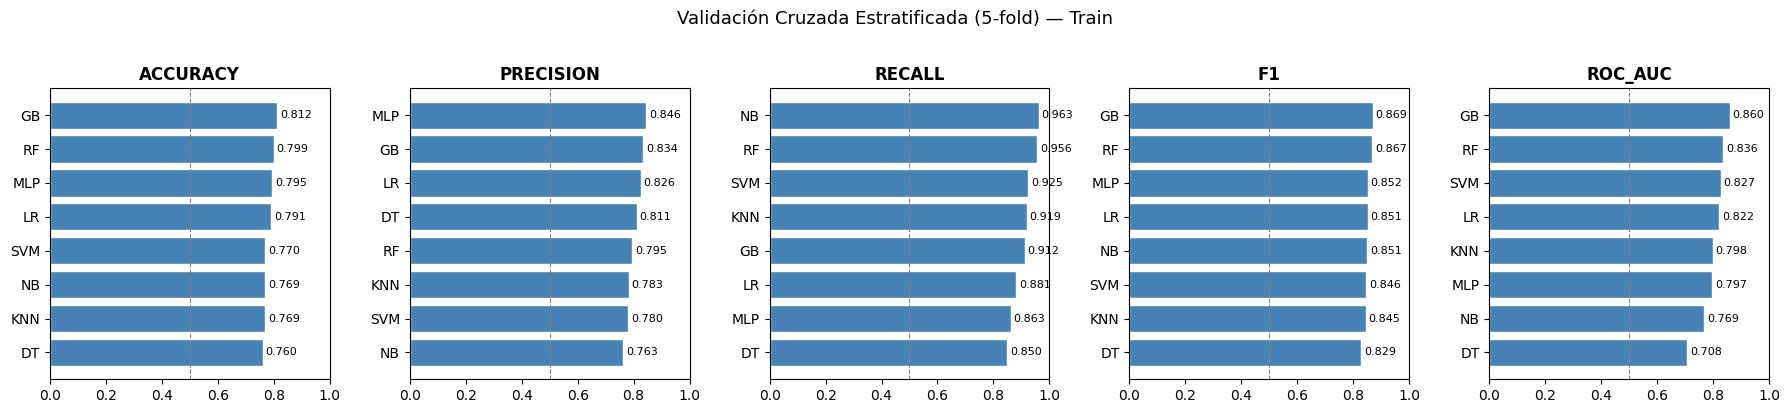

In [ ]:
# Visualización de métricas CV
fig, axes = plt.subplots(1, len(CV_METRICS), figsize=(18, 4), sharey=False)
for ax, metric in zip(axes, CV_METRICS):
    vals = cv_df[metric].sort_values(ascending=True)
    bars = ax.barh(vals.index, vals.values, color='steelblue', edgecolor='white')
    ax.set_title(metric.upper(), fontweight='bold')
    ax.set_xlim(0, 1)
    ax.axvline(0.5, ls='--', color='gray', lw=0.8)
    for bar, v in zip(bars, vals.values):
        ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=8)
plt.suptitle('Validación Cruzada Estratificada (5-fold) — Train', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Evaluación sobre el Conjunto de Prueba

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay)

# Reentrenar cada modelo con el conjunto completo de entrenamiento
fitted_models = {}
test_results  = {}

for name, model in MODELS.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    test_results[name] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_test, y_prob),
    }

test_df_results = pd.DataFrame(test_results).T
test_df_results.index.name = 'Model'
test_df_results.sort_values('roc_auc', ascending=False).round(4)

,accuracy,precision,recall,f1,roc_auc
Model,,,,,
LR,0.7759,0.8182,0.8780,0.8471,0.7834
SVM,0.7931,0.7843,0.9756,0.8696,0.7834
NB,0.7931,0.7843,0.9756,0.8696,0.7647
RF,0.7586,0.7755,0.9268,0.8444,0.7633
MLP,0.7759,0.8043,0.9024,0.8506,0.7418
KNN,0.7759,0.7917,0.9268,0.8539,0.7123
GB,0.6897,0.7556,0.8293,0.7907,0.7030
DT,0.6724,0.7500,0.8049,0.7765,0.5789


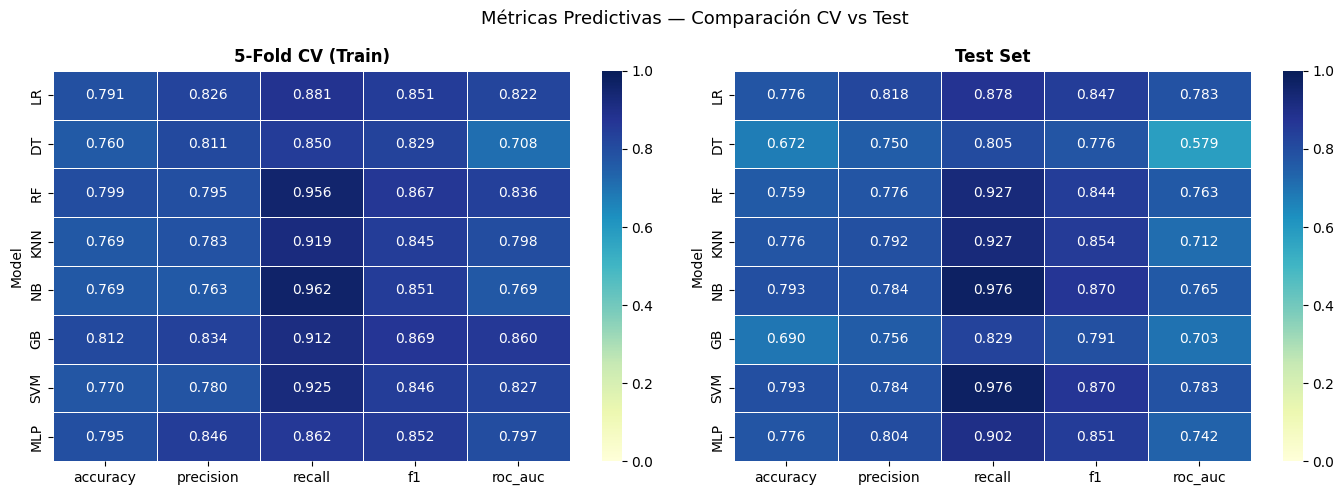

In [ ]:
# Heatmap comparativo CV vs Test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (df, title) in zip(axes, [
    (cv_df.round(3), '5-Fold CV (Train)'),
    (test_df_results.round(3), 'Test Set')
]):
    sns.heatmap(df, annot=True, fmt='.3f', cmap='YlGnBu',
                vmin=0, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('Métricas Predictivas — Comparación CV vs Test', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Selección de los Mejores Modelos

Se seleccionan los modelos con **F1-Score ≥ umbral** sobre el conjunto de prueba. Ajustá `TOP_N` o `F1_THRESHOLD` según tus resultados.

In [ ]:
# ── Parámetros de selección ───────────────────────────────────────────────────
RANK_BY     = 'f1'    # métrica principal de ordenamiento
TOP_N       = 3       # cantidad de modelos a seleccionar

# Ordenar y seleccionar
ranked = test_df_results.sort_values(RANK_BY, ascending=False)
selected_names  = ranked.head(TOP_N).index.tolist()
selected_models = {n: fitted_models[n] for n in selected_names}

print(f"Modelos seleccionados para el análisis de explicabilidad:")
for i, name in enumerate(selected_names, 1):
    row = test_df_results.loc[name]
    print(f"  {i}. {name:5s} | F1={row['f1']:.3f}  AUC={row['roc_auc']:.3f}")

ranked.head(TOP_N).style.background_gradient(cmap='YlGn', axis=0)

Modelos seleccionados para el análisis de explicabilidad:
  1. SVM   | F1=0.870  AUC=0.783
  2. NB    | F1=0.870  AUC=0.765
  3. KNN   | F1=0.854  AUC=0.712


,accuracy,precision,recall,f1,roc_auc
Model,,,,,
SVM,0.793103,0.784314,0.975610,0.869565,0.783357
NB,0.793103,0.784314,0.975610,0.869565,0.764706
KNN,0.775862,0.791667,0.926829,0.853933,0.712339


## 6. Generación de Explicaciones: SHAP y LIME

Para cada modelo seleccionado se generan las atribuciones locales de características sobre el conjunto de test.

In [ ]:
import shap
import lime
import lime.lime_tabular

# Diccionarios finales: model_name -> matriz (n_test x n_features)
shap_attributions = {}
lime_attributions = {}

# ── LIME explainer (compartido, agnóstico al modelo) ─────────────────────────
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=['nontox', 'tox'],
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

N_LIME_FEATURES = len(feature_names)   # explicar todas las features

for name, model in selected_models.items():
    print(f"\n{'='*55}")
    print(f"  Modelo: {name}")
    print(f"{'='*55}")

    # ── SHAP ─────────────────────────────────────────────────────────────────
    print("  [SHAP] Calculando valores...")
    # Extraer el estimador final si el modelo es un Pipeline
    if hasattr(model, 'named_steps'):
        inner = model.named_steps[list(model.named_steps.keys())[-1]]
        # Transformar X con el preprocesado del pipeline
        steps_before_clf = list(model.named_steps.keys())[:-1]
        X_tr_transformed = X_train.copy()
        X_te_transformed = X_test.copy()
        for step_name in steps_before_clf:
            X_tr_transformed = model.named_steps[step_name].transform(X_tr_transformed)
            X_te_transformed = model.named_steps[step_name].transform(X_te_transformed)
        predict_fn = model.predict_proba
    else:
        inner = model
        X_tr_transformed = X_train
        X_te_transformed = X_test
        predict_fn = model.predict_proba

    # Elegir el explainer SHAP más adecuado según el tipo de modelo
    tree_models = (RandomForestClassifier, GradientBoostingClassifier,
                   DecisionTreeClassifier)
    if isinstance(inner, tree_models):
        shap_exp = shap.TreeExplainer(inner)
        shap_vals = shap_exp.shap_values(X_te_transformed)
        # TreeExplainer devuelve lista [class0, class1] para clasificación
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]   # clase positiva (tox)
    else:
        # KernelSHAP: usar un background resumido para velocidad
        #background = shap.kmeans(X_tr_transformed, 30)
        #shap_exp = shap.KernelExplainer(predict_fn, background)
        #shap_vals = shap_exp.shap_values(X_te_transformed, nsamples=100)
        # ── Configuración mejorada de KernelSHAP ─────────────────────────────────────
        N_KMEANS_CLUSTERS = min(100, len(X_tr_transformed))  # más clusters
        N_SAMPLES_SHAP    = 2 * len(feature_names) + 2048    # mínimo teórico (~2102)

        background = shap.kmeans(X_tr_transformed, N_KMEANS_CLUSTERS)
        shap_exp   = shap.KernelExplainer(predict_fn, background)
        shap_vals  = shap_exp.shap_values(
            X_te_transformed,
            nsamples=N_SAMPLES_SHAP,
            l1_reg='auto'
        )
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]
    shap_attributions[name] = shap_vals   # shape: (n_test, n_features)
    print(f"  [SHAP] Listo. Shape: {shap_vals.shape}")

    # ── LIME ─────────────────────────────────────────────────────────────────
    print("  [LIME] Calculando explicaciones locales...")
    lime_matrix = np.zeros((len(X_test), len(feature_names)))
    for i in range(len(X_test)):
        exp = lime_explainer.explain_instance(
            X_test[i],
            model.predict_proba,
            num_features=N_LIME_FEATURES,
            labels=(1,)   # clase positiva
        )
        # Mapear atribuciones de vuelta al orden original de features
        feat_map = dict(exp.as_list(label=1))
        for j, fname in enumerate(feature_names):
            # LIME nombra la feature con su valor discretizado
            matched = [v for k, v in feat_map.items() if fname in k]
            lime_matrix[i, j] = matched[0] if matched else 0.0

    lime_attributions[name] = lime_matrix
    print(f"  [LIME] Listo. Shape: {lime_matrix.shape}")

print("\n✅ Explicaciones generadas para todos los modelos.")


  Modelo: SVM
  [SHAP] Calculando valores...


  0%|          | 0/58 [00:00<?, ?it/s]

  [SHAP] Listo. Shape: (58, 27, 2)
  [LIME] Calculando explicaciones locales...
  [LIME] Listo. Shape: (58, 27)

  Modelo: NB
  [SHAP] Calculando valores...


  0%|          | 0/58 [00:00<?, ?it/s]

  [SHAP] Listo. Shape: (58, 27, 2)
  [LIME] Calculando explicaciones locales...
  [LIME] Listo. Shape: (58, 27)

  Modelo: KNN
  [SHAP] Calculando valores...


  0%|          | 0/58 [00:00<?, ?it/s]

  [SHAP] Listo. Shape: (58, 27, 2)
  [LIME] Calculando explicaciones locales...
  [LIME] Listo. Shape: (58, 27)

✅ Explicaciones generadas para todos los modelos.


### 6.1 Visualizaciones de las Explicaciones


--- SHAP Summary: SVM ---


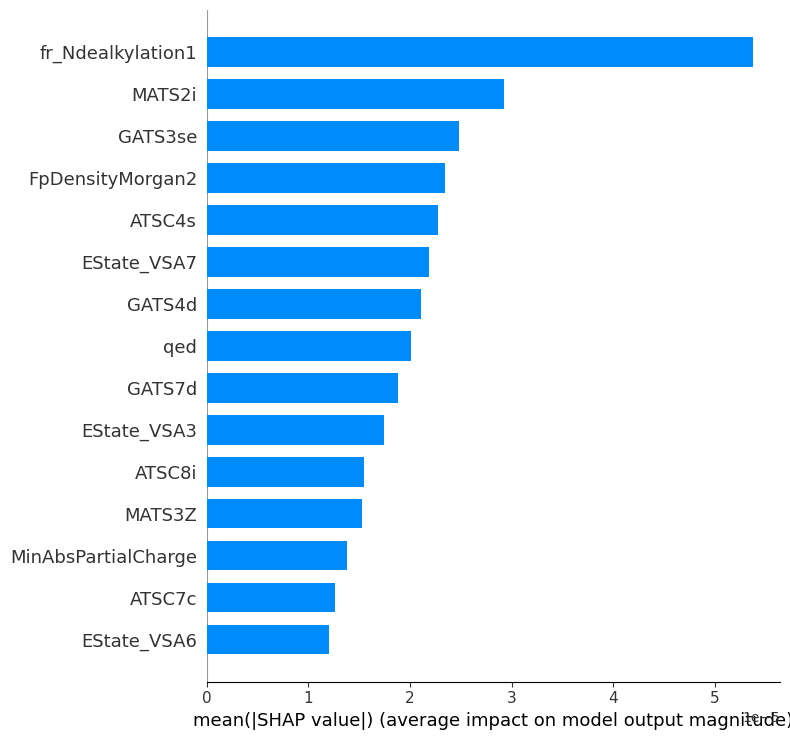


--- SHAP Summary: NB ---


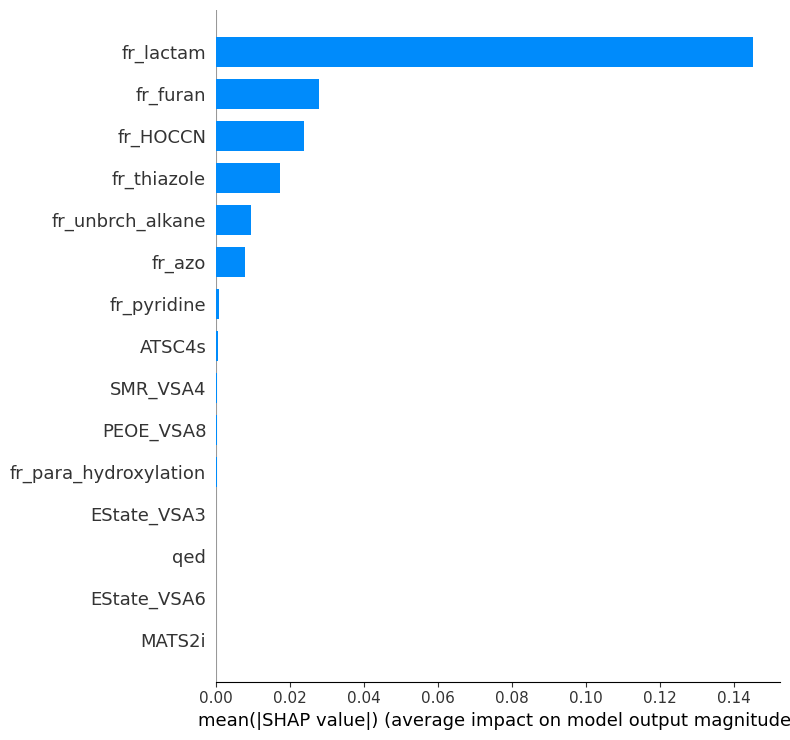


--- SHAP Summary: KNN ---


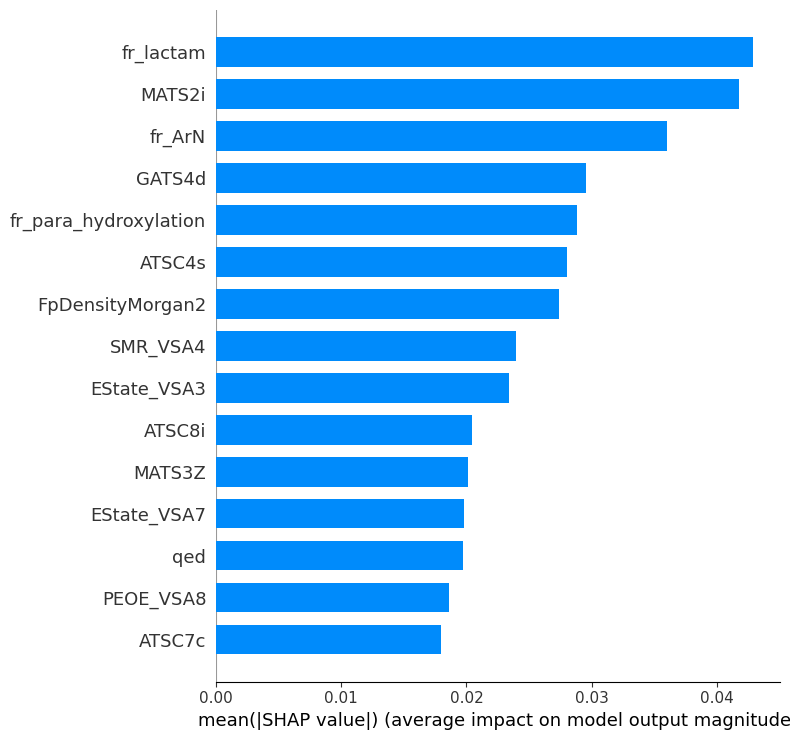

In [ ]:
# ── SHAP summary plots ────────────────────────────────────────────────────────
for name in selected_names:
    print(f"\n--- SHAP Summary: {name} ---")
    """
    shap.summary_plot(
        shap_attributions[name],
        features=X_test,
        feature_names=feature_names,
        plot_type='bar',
        show=True,
        max_display=15
    )
    """
    # Asegurar 2D antes de pasar a summary_plot
    shap_vals_2d = shap_attributions[name]
    if shap_vals_2d.ndim == 3:
        shap_vals_2d = shap_vals_2d[:, :, 1]  # clase positiva

    shap.summary_plot(
        shap_vals_2d,          # debe ser (n_samples, n_features)
        features=X_test,
        feature_names=feature_names,
        plot_type='bar',
        max_display=15
    )

Para obtener el gráfico correcto de importancias de todas las features, la celda debería asegurarse de pasar explícitamente un array 2D:
Con esto se debería ver el ranking horizontal con las 15 features más importantes ordenadas por media del valor absoluto, que es lo que permite comparar directamente con el barplot de LIME.

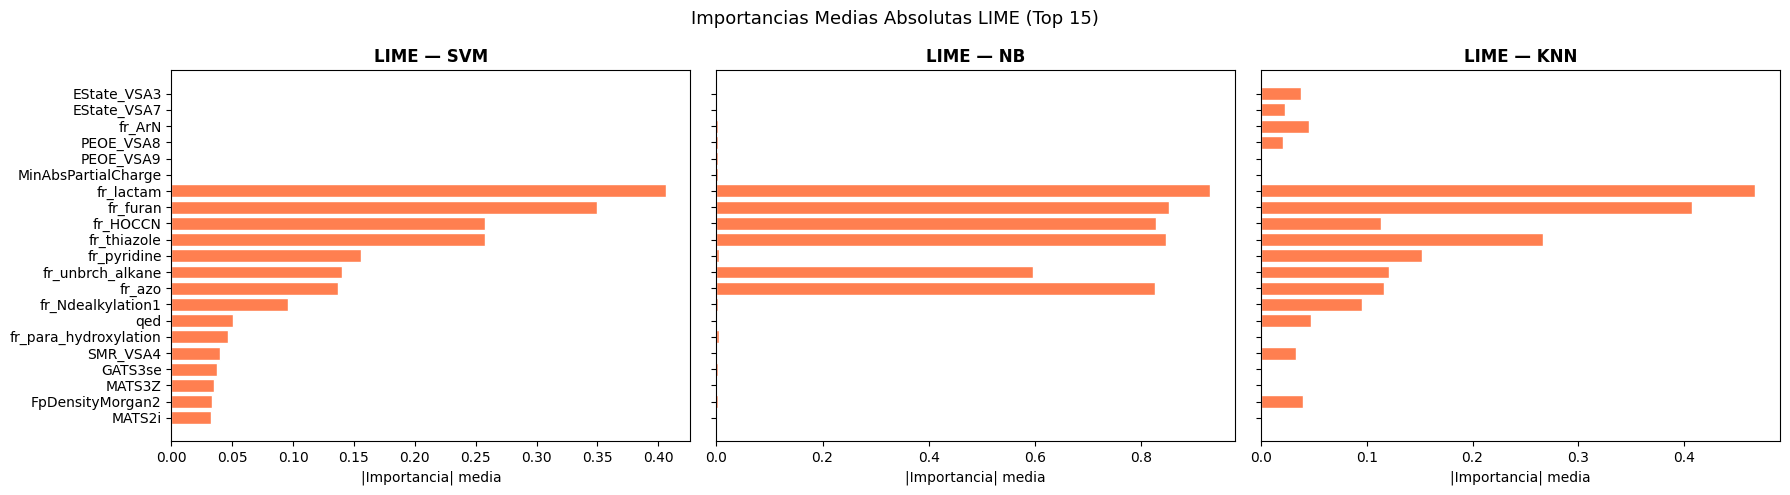

In [ ]:
# ── LIME importancias medias absolutas ───────────────────────────────────────
fig, axes = plt.subplots(1, len(selected_names),
                         figsize=(6 * len(selected_names), 5),
                         sharey=True)
if len(selected_names) == 1:
    axes = [axes]

for ax, name in zip(axes, selected_names):
    mean_abs = np.abs(lime_attributions[name]).mean(axis=0)
    idx = np.argsort(mean_abs)[-15:]  # top 15
    ax.barh([feature_names[i] for i in idx], mean_abs[idx],
            color='coral', edgecolor='white')
    ax.set_title(f'LIME — {name}', fontweight='bold')
    ax.set_xlabel('|Importancia| media')

plt.suptitle('Importancias Medias Absolutas LIME (Top 15)', fontsize=13)
plt.tight_layout()
plt.show()

**Rank Consistency** — compara el ranking de cada instancia contra la **moda** del ranking de esa feature. La desviación se normaliza por el rango máximo posible:

$$r_{ij} = \text{rank}(f_{ij}), \qquad \text{mode}_j = \text{Mode}_i\{r_{ij}\}, \qquad D_{\max,j} = \max_i r_{ij} - \min_i r_{ij}$$
$$C_j = 1 - \frac{1}{M}\sum_{i=1}^{M} \frac{|r_{ij} - \text{mode}_j|}{D_{\max,j}}, \qquad R_C = \frac{1}{d}\sum_{j=1}^{d} C_j$$

**Stability** — normaliza la varianza observada $V_j$ respecto a la varianza máxima teórica (cota de Bernoulli), y agrega ponderando por importancia media:

$$\mu_j = \frac{1}{M}\sum_{i=1}^{M} f_{ij}, \qquad V_j = \frac{1}{M-1}\sum_{i=1}^{M}(f_{ij} - \mu_j)^2$$
$$S_j = 1 - \frac{V_j}{\mu_j(1 - \mu_j)}, \qquad IS = \sum_{j=1}^{d} \frac{\mu_j}{\sum_k \mu_k} \cdot S_j$$

## 7b. Métricas HolisticAI — Implementación Original

Esta sección implementa **fielmente** las métricas del repositorio oficial
[holisticai-research](https://github.com/holistic-ai/holisticai-research),
archivos `_rank_consistency.py` y `_stability.py`, adaptadas para recibir
directamente los arrays NumPy de atribuciones SHAP / LIME.

### Diferencias clave respecto a la Sección 7

| Métrica | Sección 7 (custom) | Sección 7b (HolisticAI original) |
|---|---|---|
| **Rank Consistency** | Correlación de Spearman media entre pares | Desviación normalizada del rango modal |
| **Feature Stability** | 1 − CV ponderado de atribuciones | Densidad KNN en simplex de Dirichlet (varianza) |

Ambas métricas están en **[0, 1]** donde **1 = perfectamente consistente / estable**.

In [ ]:
#   _rank_consistency.py     rank_consistency_holistic()
#   _stability.py            feature_stability_holistic()

import numpy as np
from scipy import stats
from scipy.spatial.distance import jensenshannon
from sklearn.neighbors import NearestNeighbors
from numpy.random import RandomState

EPSILON = 1e-8

# ── rank_consistency (HolisticAI original) ───────────────────────────────────
def _local_normalized_deviation(local_importances_values: np.ndarray) -> np.ndarray:
    """Desviación normalizada del rango modal (port directo de HolisticAI)."""
    ranked_features = np.argsort(np.argsort(-local_importances_values, axis=1), axis=1)
    mode_result = stats.mode(ranked_features, axis=0, keepdims=False)
    return (np.abs(ranked_features - np.array(mode_result.mode)[None, :])) / (
        np.max(ranked_features, axis=0) - np.min(ranked_features, axis=0) + EPSILON
    )[None, :]


def rank_consistency_holistic(local_importances_values: np.ndarray,
                               weighted: bool = False) -> float:
    """
    Port directo de holisticai._rank_consistency.rank_consistency().

    Calcula 1 - desviacion_normalizada_media, de modo que
    1 = rankings perfectamente consistentes entre instancias.

    Parameters
    ----------
    local_importances_values : np.ndarray, shape (n_samples, n_features)
    weighted : bool
        Si True, pondera por la importancia media absoluta normalizada.

    Returns
    -------
    float  en [0, 1]
    """
    if local_importances_values.ndim == 3:
        local_importances_values = local_importances_values[:, :, 1]
    normalized_dev = _local_normalized_deviation(local_importances_values)
    consistencies  = np.mean(normalized_dev, axis=0)   # desviacion por feature
    if weighted:
        abs_vals = np.abs(local_importances_values)
        norm_vals = abs_vals / (abs_vals.sum(axis=1, keepdims=True) + EPSILON)
        avg_imp  = norm_vals.mean(axis=0)
        raw_score = np.sum(avg_imp * consistencies)
    else:
        raw_score = np.mean(consistencies)
    # Convertir: desviacion baja → consistencia alta → score cercano a 1
    return float(1.0 - raw_score)


# ── FeatureStability (HolisticAI original) ───────────────────────────────────
def _importances_to_simplex(local_importances_values: np.ndarray) -> np.ndarray:
    """Normaliza filas para que sumen 1 (simplex), usando valores absolutos."""
    arr = np.abs(local_importances_values).astype(float)
    row_sums = arr.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = EPSILON
    return arr / row_sums


def _compute_importance_distribution(local_importances_values: np.ndarray,
                                      k: int = 5,
                                      num_samples: int = 10000,
                                      random_state=42) -> np.ndarray:
    """
    Port directo de holisticai._stability.compute_importance_distribution().
    Muestrea puntos de una distribucion Dirichlet y estima su densidad
    usando KNN sobre las atribuciones normalizadas.
    """
    if isinstance(random_state, int):
        random_state = RandomState(random_state)

    embeddings   = _importances_to_simplex(local_importances_values)
    num_features = embeddings.shape[1]
    alpha        = 0.1

    grid = np.array([
        random_state.dirichlet(alpha * np.ones(num_features))
        for _ in range(num_samples)
    ])

    nbrs = NearestNeighbors(n_neighbors=k).fit(embeddings)
    distances, _ = nbrs.kneighbors(grid)
    densities    = 1.0 / (distances[:, -1] + 1e-10)
    densities   /= densities.sum()
    return densities


def feature_stability_holistic(local_importances_values: np.ndarray,
                                strategy: str = "variance",
                                k: int = 5,
                                num_samples: int = 10000,
                                random_state=42) -> float:
    """
    Port directo de holisticai._stability.FeatureStability.__call__().

    Parameters
    ----------
    local_importances_values : np.ndarray, shape (n_samples, n_features)
    strategy : 'variance' (default) | 'entropy'

    Returns
    -------
    float  en [0, 1]  (1 = maxima estabilidad)
    """
    if local_importances_values.ndim == 3:
        local_importances_values = local_importances_values[:, :, 1]
    densities = _compute_importance_distribution(
        local_importances_values, k=k,
        num_samples=num_samples, random_state=random_state
    )
    if strategy == "variance":
        jsd_std = np.std(densities)
        jsd_max = np.max(densities)
        return float(1.0 - (jsd_std / jsd_max))
    if strategy == "entropy":
        n = len(densities)
        uniform = np.full(n, 1.0 / n)
        return float(1.0 - jensenshannon(densities, uniform, base=2))
    raise ValueError(f"strategy invalida: {strategy}")


# ── Calcular métricas HolisticAI para SHAP y LIME ────────────────────────────
print("Calculando métricas HolisticAI (puede tardar ~1-2 min por la densidad KNN)...")
holistic_rows = []

for name in selected_names:
    for method, attr_dict in [('SHAP', shap_attributions),
                               ('LIME', lime_attributions)]:
        arr = attr_dict[name]                 # shape: (n_test, n_features)
        if arr.ndim == 3:
            arr = arr[:, :, 1]  # clase positiva
        rc  = rank_consistency_holistic(arr)
        fs  = feature_stability_holistic(arr)
        ges = 0.5 * (rc + fs)
        holistic_rows.append({
            'Model': name, 'Explainer': method,
            'HC_RankConsistency': rc,
            'HC_FeatureStability': fs,
            'HC_GES': ges,
        })
        print(f"  {name:5s} | {method:4s} | "
              f"HC_RC={rc:.4f}  HC_FS={fs:.4f} HC_GES={ges:.4f}")

holistic_df = pd.DataFrame(holistic_rows)
print("\n✅ Métricas HolisticAI calculadas.")


Calculando métricas HolisticAI (puede tardar ~1-2 min por la densidad KNN)...
  SVM   | SHAP | HC_RC=0.7458  HC_FS=0.9018 HC_GES=0.8238
  SVM   | LIME | HC_RC=0.7809  HC_FS=0.9095 HC_GES=0.8452
  NB    | SHAP | HC_RC=0.8103  HC_FS=0.9561 HC_GES=0.8832
  NB    | LIME | HC_RC=0.7260  HC_FS=0.9081 HC_GES=0.8171
  KNN   | SHAP | HC_RC=0.7179  HC_FS=0.8941 HC_GES=0.8060
  KNN   | LIME | HC_RC=0.7877  HC_FS=0.9180 HC_GES=0.8529

✅ Métricas HolisticAI calculadas.


## 8. Análisis Comparativo y Criterio de Selección

> Agregar bloque entrecomillado



Se calcula para cada modelo:
- **∆RankConsistency** = |RC_SHAP − RC_LIME|
- **∆Stability** = |Stab_SHAP − Stab_LIME|
- **∆Global** = |GES_SHAP − GES_LIME|

In [ ]:
print('Análisis Comparativo y Criterio de Selección HolisticAI 7.b')
comparison_rows = []
for name in selected_names:
    # Fetch metrics for SHAP from the holistic_df
    shap_m = holistic_df[(holistic_df.Model == name) &
                         (holistic_df.Explainer == 'SHAP')].iloc[0]
    # Fetch metrics for LIME from the holistic_df
    lime_m = holistic_df[(holistic_df.Model == name) &
                         (holistic_df.Explainer == 'LIME')].iloc[0]

    # Calculate deltas using HolisticAI metrics
    delta_rc  = abs(shap_m['HC_RankConsistency'] - lime_m['HC_RankConsistency'])
    delta_st  = abs(shap_m['HC_FeatureStability']       - lime_m['HC_FeatureStability'])
    delta_ges = abs(shap_m['HC_GES']             - lime_m['HC_GES'])

    # ── Criterio de selección ────────────────────────────────────────────────
    # Use HolisticAI metrics for comparison criteria
    shap_wins_rc = shap_m['HC_RankConsistency'] > lime_m['HC_RankConsistency']
    shap_wins_st = shap_m['HC_FeatureStability']       > lime_m['HC_FeatureStability']

    if shap_wins_rc and shap_wins_st:
        winner = 'SHAP'
        criterion = 'Dominancia'
    elif not shap_wins_rc and not shap_wins_st:
        winner = 'LIME'
        criterion = 'Dominancia'
    else:
        winner = 'SHAP' if shap_m['HC_GES'] >= lime_m['HC_GES'] else 'LIME'
        criterion = 'GES (trade-off)'

    comparison_rows.append({
        'Model':             name,
        # Append HolisticAI metrics to the comparison table
        'HC_RC_SHAP':           shap_m['HC_RankConsistency'],
        'HC_RC_LIME':           lime_m['HC_RankConsistency'],
        'HC_Stab_SHAP':         shap_m['HC_FeatureStability'],
        'HC_Stab_LIME':         lime_m['HC_FeatureStability'],
        'HC_GES_SHAP':          shap_m['HC_GES'],
        'HC_GES_LIME':          lime_m['HC_GES'],
        'HC_∆RankConsistency':  delta_rc,
        'HC_∆Stability':        delta_st,
        'HC_∆Global':           delta_ges,
        'HC_Winner':            winner,
        'HC_Criterion':         criterion,
    })

comparison_df = pd.DataFrame(comparison_rows).set_index('Model')
comparison_df.round(4)

Análisis Comparativo y Criterio de Selección HolisticAI 7.b


,HC_RC_SHAP,HC_RC_LIME,HC_Stab_SHAP,HC_Stab_LIME,HC_GES_SHAP,HC_GES_LIME,HC_∆RankConsistency,HC_∆Stability,HC_∆Global,HC_Winner,HC_Criterion
Model,,,,,,,,,,,
SVM,0.7458,0.7809,0.9018,0.9095,0.8238,0.8452,0.0352,0.0077,0.0214,LIME,Dominancia
NB,0.8103,0.7260,0.9561,0.9081,0.8832,0.8171,0.0843,0.0480,0.0661,SHAP,Dominancia
KNN,0.7179,0.7877,0.8941,0.9180,0.8060,0.8529,0.0698,0.0239,0.0468,LIME,Dominancia


In [ ]:
# ── Resumen de ganadores ──────────────────────────────────────────────────────
print("=" * 60)
print("RESUMEN: Método de explicabilidad preferido por modelo para HC_7.b")
print("=" * 60)
for name, row in comparison_df.iterrows():
    print(f"  {name:5s} → {row['HC_Winner']:4s}  ({row['HC_Criterion']})")
    print(f"         SHAP: RC={row['HC_RC_SHAP']:.4f}  Stab={row['HC_Stab_SHAP']:.4f}  GES={row['HC_GES_SHAP']:.4f}")
    print(f"         LIME: RC={row['HC_RC_LIME']:.4f}  Stab={row['HC_Stab_LIME']:.4f}  GES={row['HC_GES_LIME']:.4f}")
    print(f"         Δ:   RC={row['HC_∆RankConsistency']:.4f}  Stab={row['HC_∆Stability']:.4f}  ΔGlobal={row['HC_∆Global']:.4f}")
    print()

RESUMEN: Método de explicabilidad preferido por modelo para HC_7.b
  SVM   → LIME  (Dominancia)
         SHAP: RC=0.7458  Stab=0.9018  GES=0.8238
         LIME: RC=0.7809  Stab=0.9095  GES=0.8452
         Δ:   RC=0.0352  Stab=0.0077  ΔGlobal=0.0214

  NB    → SHAP  (Dominancia)
         SHAP: RC=0.8103  Stab=0.9561  GES=0.8832
         LIME: RC=0.7260  Stab=0.9081  GES=0.8171
         Δ:   RC=0.0843  Stab=0.0480  ΔGlobal=0.0661

  KNN   → LIME  (Dominancia)
         SHAP: RC=0.7179  Stab=0.8941  GES=0.8060
         LIME: RC=0.7877  Stab=0.9180  GES=0.8529
         Δ:   RC=0.0698  Stab=0.0239  ΔGlobal=0.0468



### 8.1 Visualización del Análisis Comparativo

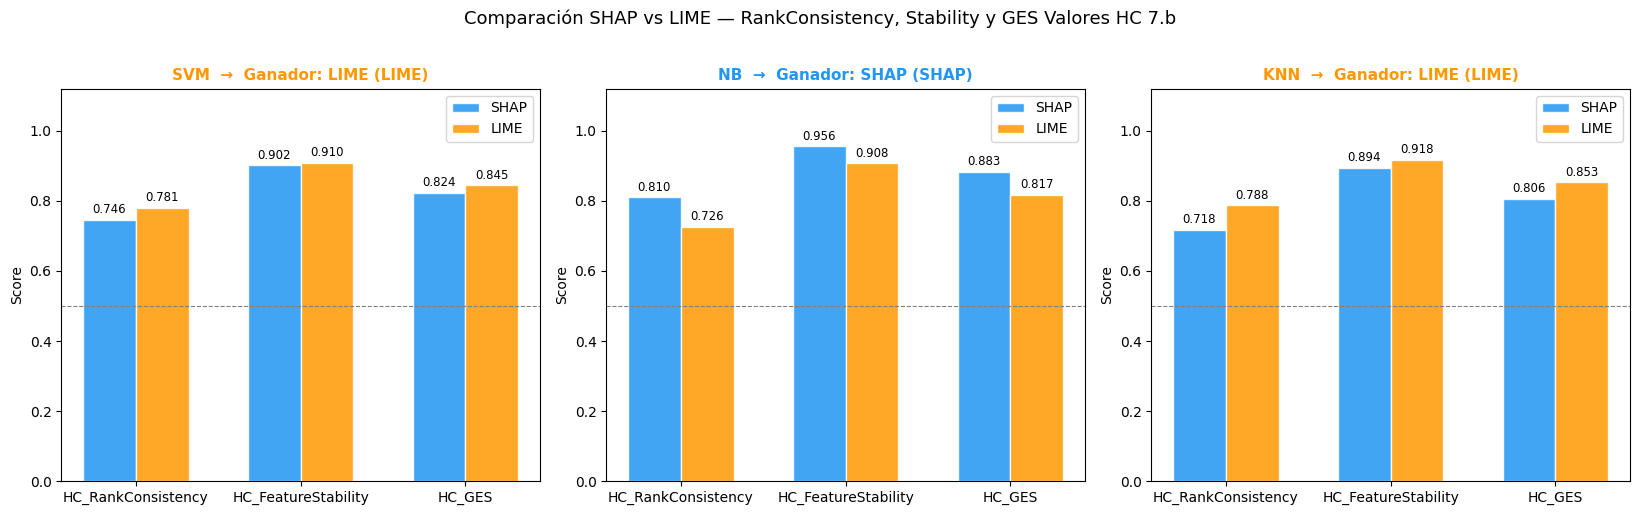

In [ ]:
n_models = len(selected_names)
fig, axes = plt.subplots(1, n_models, figsize=(5.5 * n_models, 5))
if n_models == 1:
    axes = [axes]

colors = {'SHAP': '#2196F3', 'LIME': '#FF9800'}
metrics_to_plot = ['HC_RankConsistency', 'HC_FeatureStability', 'HC_GES']

for ax, name in zip(axes, selected_names):
    x = np.arange(len(metrics_to_plot))
    w = 0.32
    for offset, method in zip([-w/2, w/2], ['SHAP', 'LIME']):
        row = holistic_df[(holistic_df.Model == name) &
                          (holistic_df.Explainer == method)].iloc[0]
        vals = [row[m] for m in metrics_to_plot]
        bars = ax.bar(x + offset, vals, w, label=method,
                      color=colors[method], edgecolor='white', alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8.5)

    # Use 'HC_Winner' and 'HC_Winner' from the comparison_df
    winner = comparison_df.loc[name, 'HC_Winner']
    criterion = comparison_df.loc[name, 'HC_Winner']
    ax.set_title(f'{name}  →  Ganador: {winner} ({criterion})',
                 fontsize=11, fontweight='bold',
                 color=colors[winner])
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_to_plot, fontsize=10)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Score')
    ax.axhline(0.5, ls='--', lw=0.8, color='gray')
    ax.legend()

plt.suptitle('Comparación SHAP vs LIME — RankConsistency, Stability y GES Valores HC 7.b',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

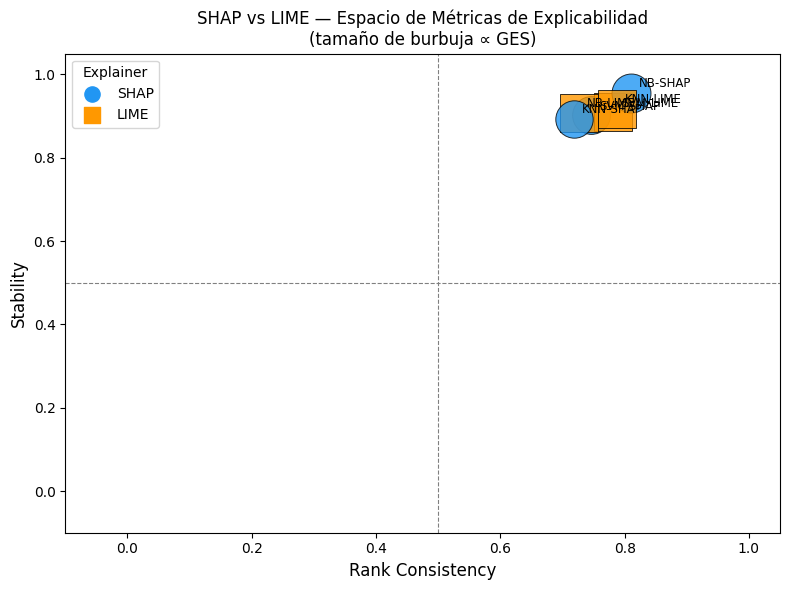

In [ ]:
# ── Scatter: Stability vs Rank Consistency (bubble = GES) ────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
markers = {'SHAP': 'o', 'LIME': 's'}

for _, row in holistic_df.iterrows():
    c = colors[row['Explainer']]
    sc = ax.scatter(row['HC_RankConsistency'], row['HC_FeatureStability'],
                    s=row['HC_GES'] * 800 + 80,
                    color=c, marker=markers[row['Explainer']],
                    alpha=0.8, edgecolors='k', linewidths=0.7)
    ax.annotate(f"{row['Model']}-{row['Explainer']}",
                xy=(row['HC_RankConsistency'], row['HC_FeatureStability']),
                xytext=(6, 4), textcoords='offset points', fontsize=8.5)

# Leyenda manual
for method, marker in markers.items():
    ax.scatter([], [], s=120, color=colors[method], marker=marker, label=method)
ax.legend(title='Explainer', fontsize=10)

ax.axhline(0.5, ls='--', lw=0.8, color='gray')
ax.axvline(0.5, ls='--', lw=0.8, color='gray')
ax.set_xlabel('Rank Consistency', fontsize=12)
ax.set_ylabel('Stability', fontsize=12)
ax.set_title('SHAP vs LIME — Espacio de Métricas de Explicabilidad\n'
             '(tamaño de burbuja ∝ GES)', fontsize=12)
ax.set_xlim(-0.1, 1.05)
ax.set_ylim(-0.1, 1.05)
plt.tight_layout()
plt.show()

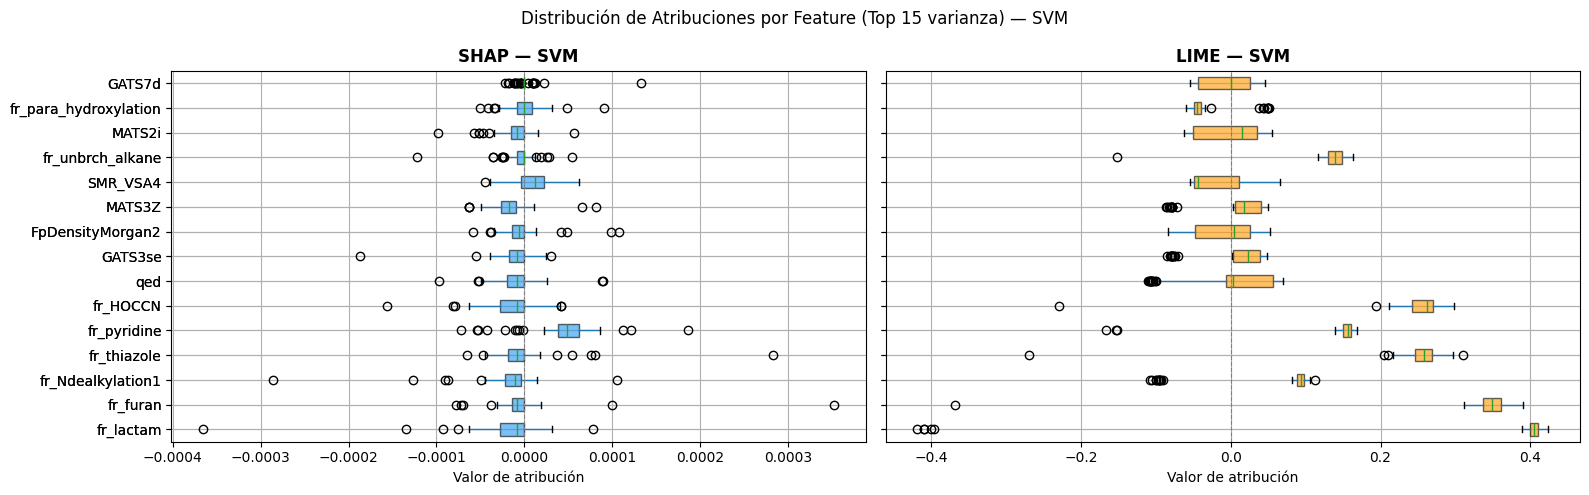

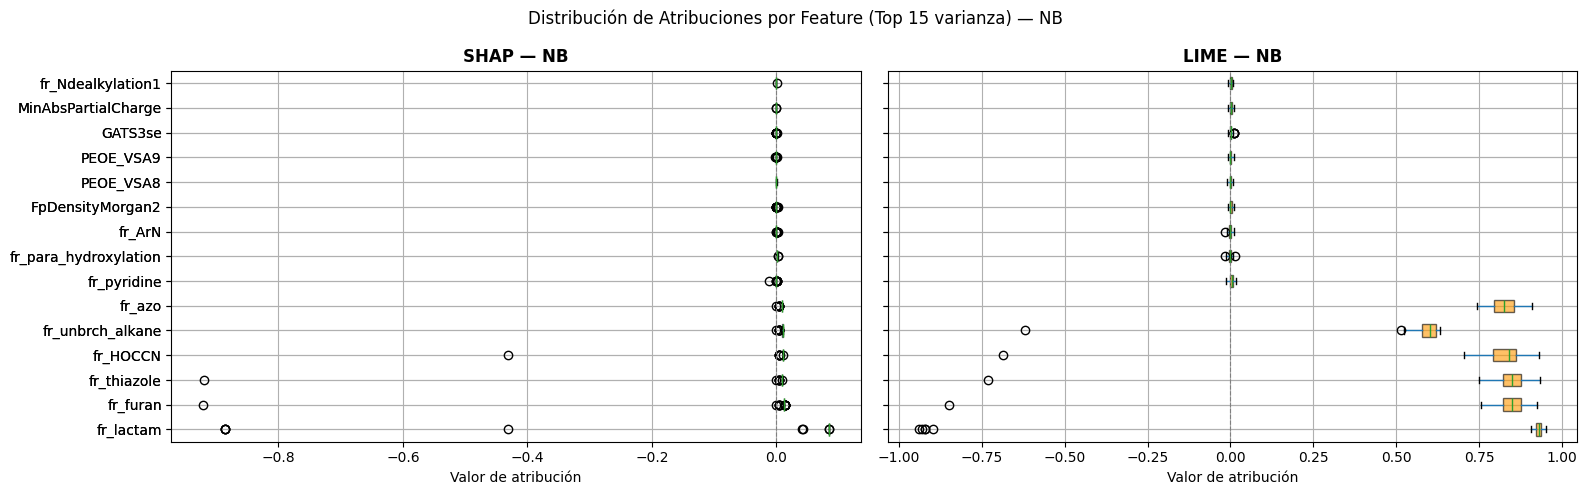

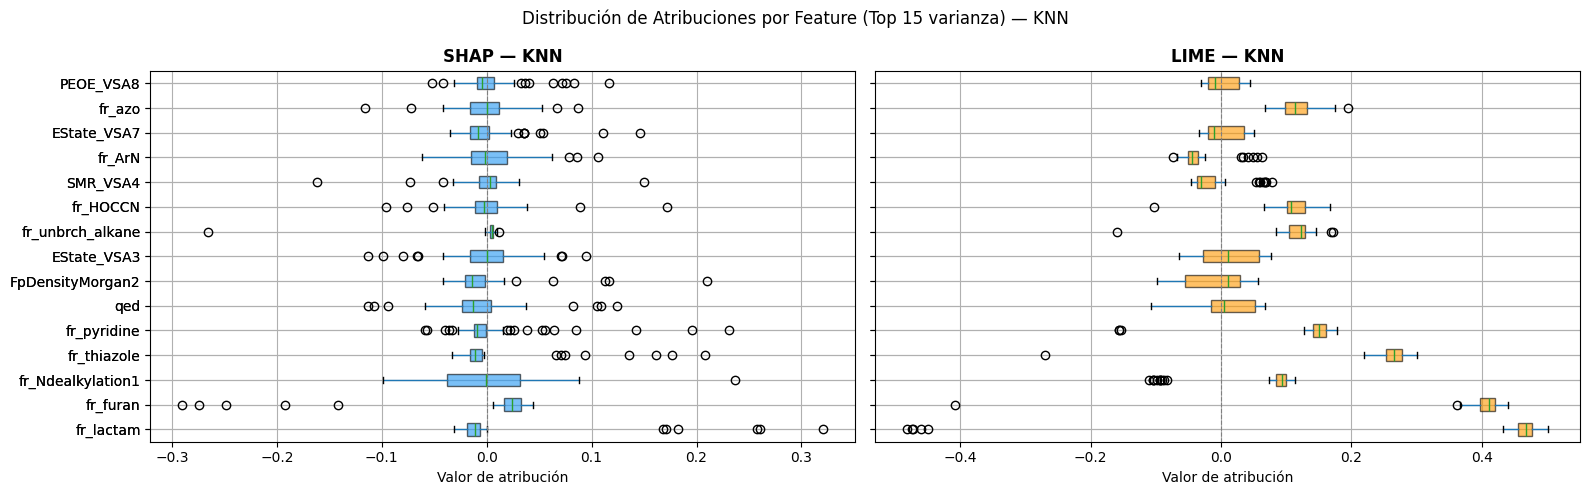

In [ ]:
# ── Estabilidad por feature (boxplots SHAP vs LIME) ──────────────────────────
for name in selected_names:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    for ax, (method, attr) in zip(axes,
        [('SHAP', shap_attributions[name]),
         ('LIME', lime_attributions[name])]):

        # Asegurar que attr sea 2D (n_samples, n_features)
        if attr.ndim == 3:
            attr = attr[:, :, 1]   # tomar clase positiva (tox)

        df_box = pd.DataFrame(attr, columns=feature_names)
        order = df_box.std().sort_values(ascending=False).index[:15]
        df_box[order].boxplot(ax=ax, vert=False,
                               patch_artist=True,
                               boxprops=dict(facecolor=colors[method], alpha=0.6))
        ax.set_title(f'{method} — {name}', fontweight='bold')
        ax.set_xlabel('Valor de atribución')
        ax.axvline(0, ls='--', lw=0.8, color='gray')

    plt.suptitle(f'Distribución de Atribuciones por Feature (Top 15 varianza) — {name}',
                 fontsize=12)
    plt.tight_layout()
    plt.show()

### 8.2 Diferencias ∆ entre métodos

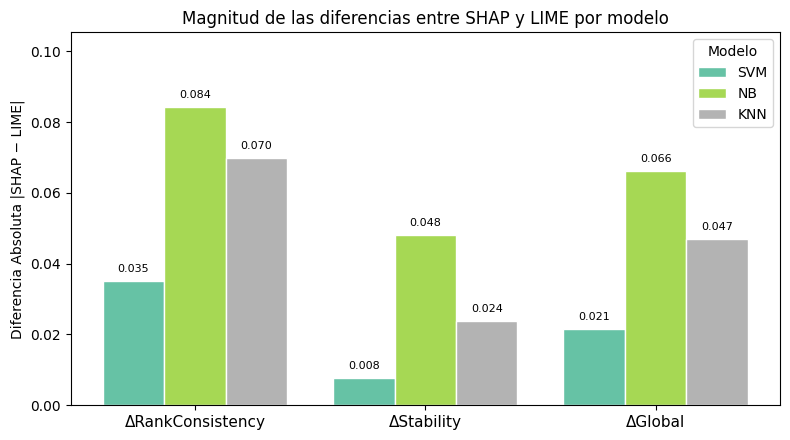

In [ ]:
delta_cols = ['HC_∆RankConsistency', 'HC_∆Stability', 'HC_∆Global']
delta_data = comparison_df[delta_cols].copy()

fig, ax = plt.subplots(figsize=(8, max(3, n_models * 1.5)))
x = np.arange(len(delta_cols))
w = 0.8 / n_models
palette = plt.cm.Set2(np.linspace(0, 1, n_models))

for i, (name, row) in enumerate(delta_data.iterrows()):
    offset = (i - n_models / 2 + 0.5) * w
    bars = ax.bar(x + offset, row.values, w,
                  label=name, color=palette[i], edgecolor='white')
    for bar, v in zip(bars, row.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(['ΔRankConsistency', 'ΔStability', 'ΔGlobal'], fontsize=11)
ax.set_ylabel('Diferencia Absoluta |SHAP − LIME|')
ax.set_title('Magnitud de las diferencias entre SHAP y LIME por modelo', fontsize=12)
ax.legend(title='Modelo')
ax.set_ylim(0, max(delta_data.values.max() * 1.25, 0.1))
plt.tight_layout()
plt.show()

## 9. Conclusión Final

In [ ]:
print("╔" + "═" * 62 + "╗")
print("║   CONCLUSIÓN: Selección del Método de Explicabilidad        ║")
print("╠" + "═" * 62 + "╣")
for name, row in comparison_df.iterrows():
    gap = 62 - len(name) - len(row['HC_Winner']) - len(row['HC_Criterion']) - 14
    print(f"║  Modelo {name}:  {row['HC_Winner']} es preferido  [{row['HC_Criterion']}]{' ' * max(0, gap)}║")
print("╠" + "═" * 62 + "╣")

# Ganador global por GES medio
ges_shap = comparison_df['HC_GES_SHAP'].mean()
ges_lime = comparison_df['HC_GES_LIME'].mean()
global_winner = 'SHAP' if ges_shap >= ges_lime else 'LIME'
print(f"║  GES medio global — SHAP: {ges_shap:.4f} | LIME: {ges_lime:.4f}       ║")
print(f"║  ➤  Método preferido globalmente: {global_winner:4s}                   ║")
print("╚" + "═" * 62 + "╝")

╔══════════════════════════════════════════════════════════════╗
║   CONCLUSIÓN: Selección del Método de Explicabilidad        ║
╠══════════════════════════════════════════════════════════════╣
║  Modelo SVM:  LIME es preferido  [Dominancia]                               ║
║  Modelo NB:  SHAP es preferido  [Dominancia]                                ║
║  Modelo KNN:  LIME es preferido  [Dominancia]                               ║
╠══════════════════════════════════════════════════════════════╣
║  GES medio global — SHAP: 0.8377 | LIME: 0.8384       ║
║  ➤  Método preferido globalmente: LIME                   ║
╚══════════════════════════════════════════════════════════════╝


---
## Referencias

- Munoz, C., da Costa, K., Modenesi, B., & Koshiyama, A. (2023). *Evaluating explainability in machine learning predictions through explainer-agnostic metrics*. arXiv:2302.12094.
- Togo, M. V. et al. (2022). TIRESIA: an explainable artificial intelligence platform for predicting developmental toxicity. *Journal of Chemical Information and Modeling*, 63(1), 56–66.
- Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting model predictions. *NeurIPS*.
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). 'Why should I trust you?': Explaining the predictions of any classifier. *KDD*.

---
## Bloque 1 — Casos de mayor desacuerdo SHAP vs LIME

Para cada instancia del test, calcular la distancia entre los rankings de ambos métodos (tau de Kendall o diferencia de Spearman). Mostrar las top-K instancias donde más discrepan, junto con:

Los valores reales de sus features
Las atribuciones de cada método lado a lado
Si el modelo acertó o erró la predicción

La conjetura explorable: ¿los desacuerdos ocurren más en instancias cercanas a la frontera de decisión (probabilidad ~0.5)? ¿O en moléculas atípicas (outliers en el espacio de features)?

In [ ]:
## Celda 1 — Setup del análisis cualitativo
# ── Setup Sección 10 ──────────────────────────────────────────────────────────
from scipy.stats import kendalltau
from scipy.spatial.distance import cdist

# Usamos el primer modelo seleccionado como caso de estudio principal
# Podés cambiar MODEL_FOCUS a cualquiera de selected_names
MODEL_FOCUS = selected_names[0]

# Asegurar 2D (por si TreeExplainer devolvió 3D)
shap_attr = shap_attributions[MODEL_FOCUS]
lime_attr = lime_attributions[MODEL_FOCUS]
if shap_attr.ndim == 3:
    shap_attr = shap_attr[:, :, 1]
if lime_attr.ndim == 3:
    lime_attr = lime_attr[:, :, 1]

n_test = len(X_test)
model  = fitted_models[MODEL_FOCUS]
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
correct = (y_pred == y_test)

print(f"Modelo de análisis: {MODEL_FOCUS}")
print(f"Instancias test: {n_test}  |  Correctas: {correct.sum()}  |  Erróneas: {(~correct).sum()}")

Modelo de análisis: SVM
Instancias test: 58  |  Correctas: 46  |  Erróneas: 12


Top instancias con mayor desacuerdo SHAP vs LIME
────────────────────────────────────────────────────────────
  #1  inst= 41 | distancia=0.991 | prob_tox=0.950 | real=tox | pred=tox | ✓
  #2  inst= 27 | distancia=0.963 | prob_tox=0.797 | real=tox | pred=tox | ✓
  #3  inst= 21 | distancia=0.954 | prob_tox=0.933 | real=tox | pred=tox | ✓
  #4  inst= 31 | distancia=0.945 | prob_tox=0.925 | real=tox | pred=tox | ✓
  #5  inst= 16 | distancia=0.940 | prob_tox=0.876 | real=tox | pred=tox | ✓


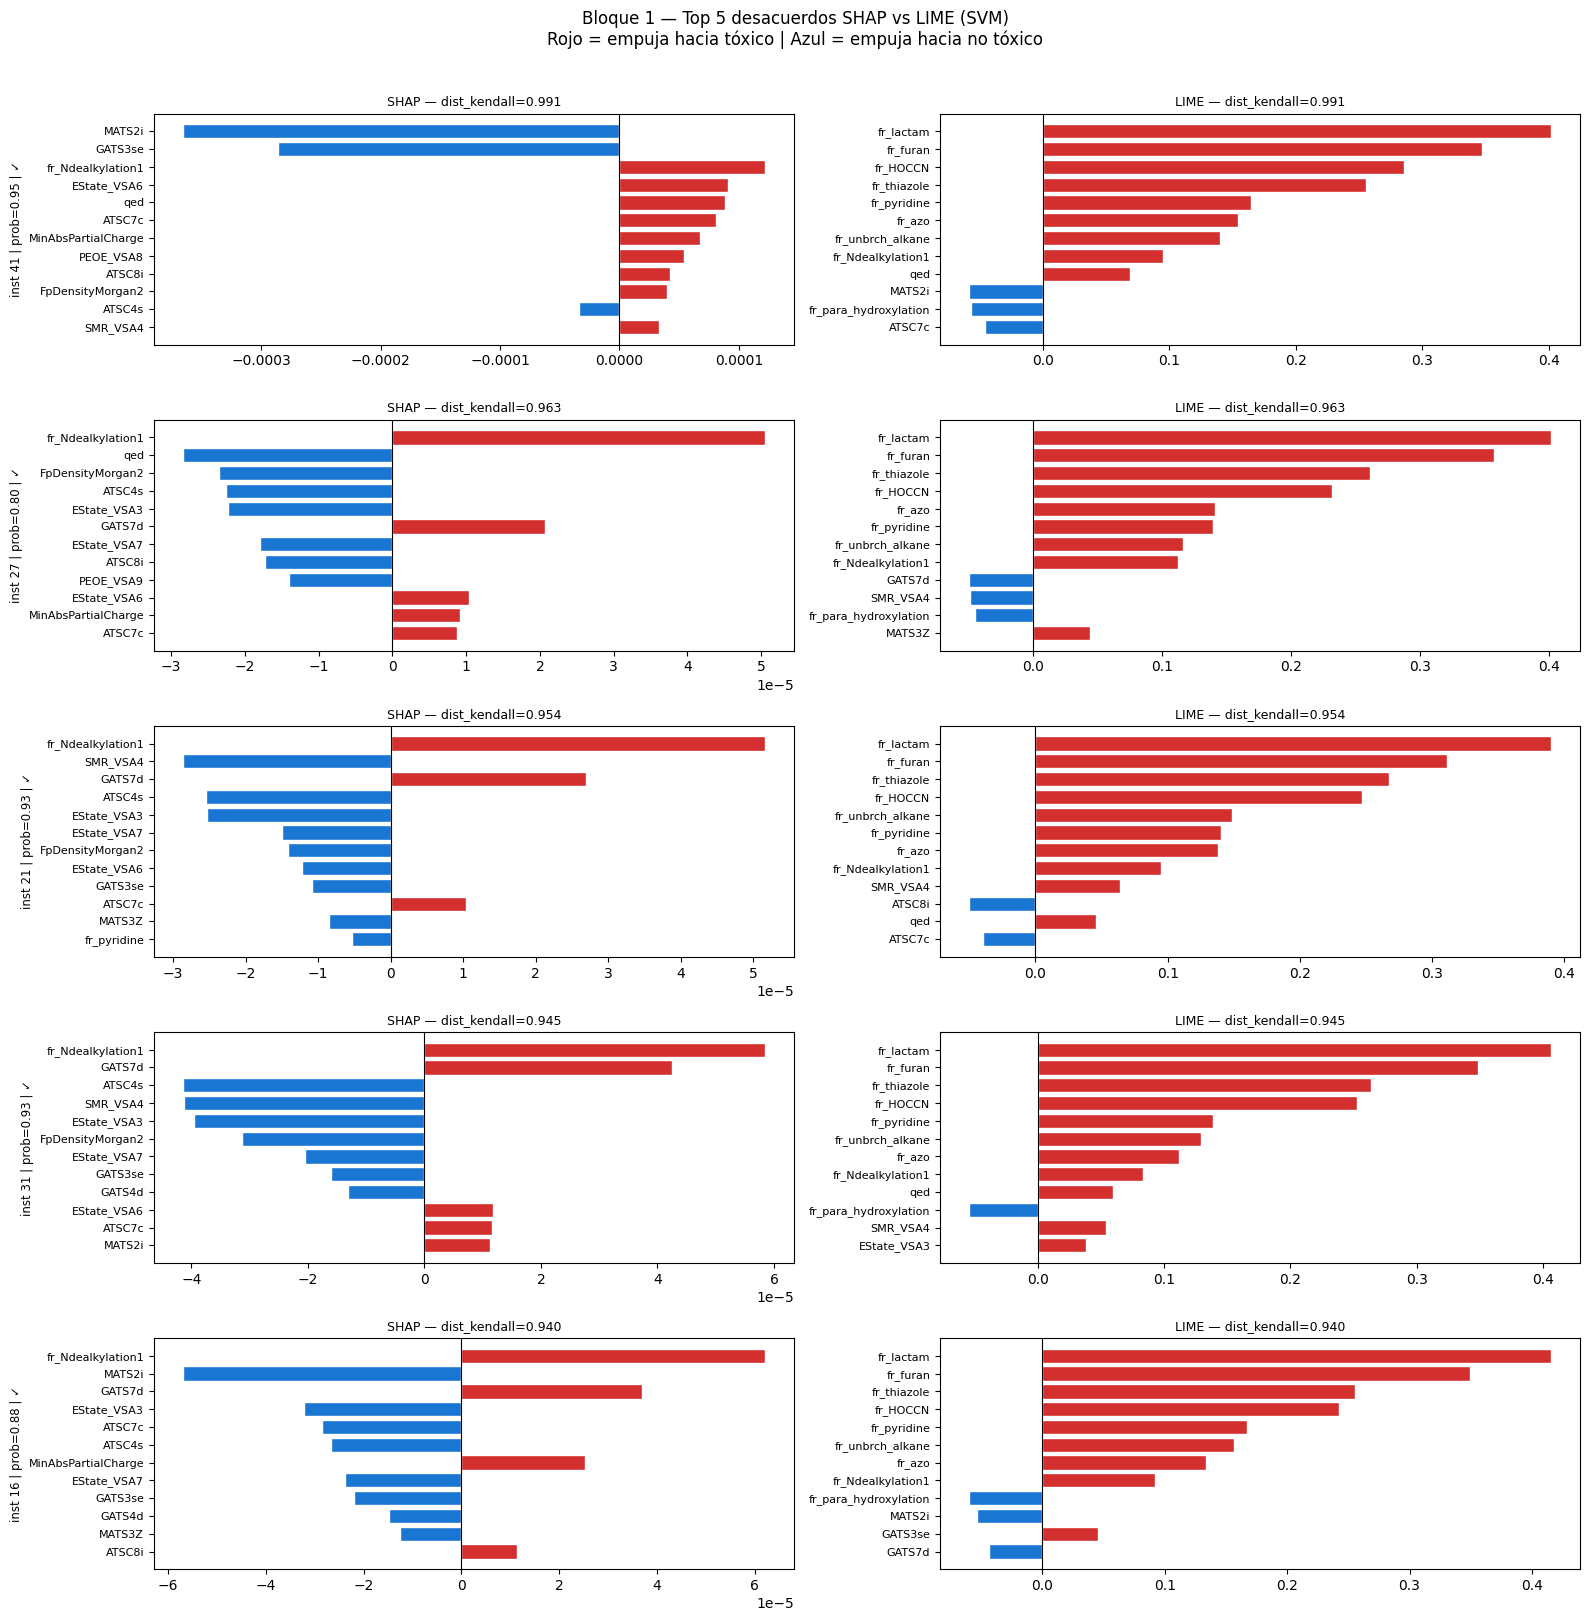

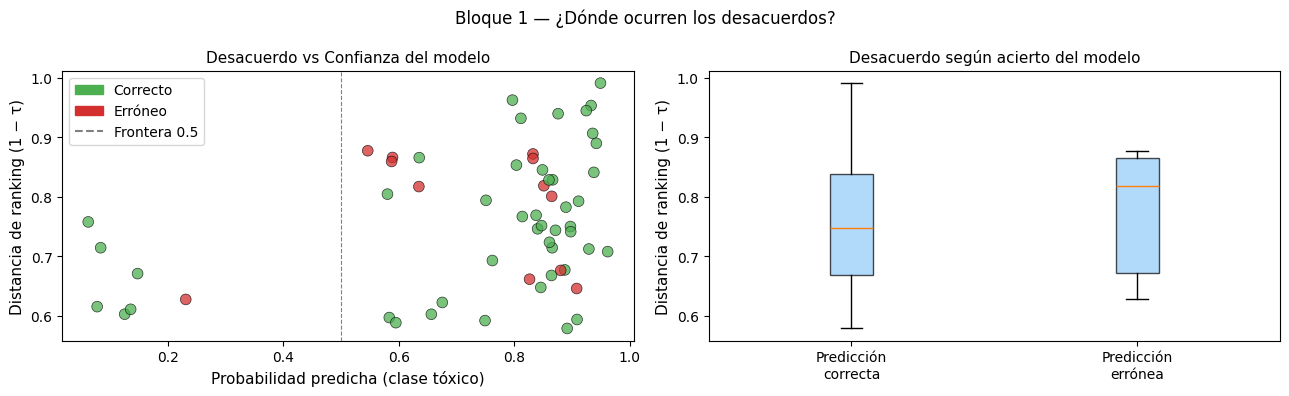


CONJETURA — Bloque 1
  Correlación |prob - 0.5| vs desacuerdo: 0.062
  Desacuerdo medio en zona frontera (0.35-0.65): 0.785  (n=8)
  Desacuerdo medio fuera de frontera:            0.757  (n=50)
  Desacuerdo medio en errores:  0.782
  Desacuerdo medio en aciertos: 0.755


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 1 — Instancias con mayor desacuerdo entre SHAP y LIME
# ══════════════════════════════════════════════════════════════════════════════
#Celda 2 — Bloque 1: Casos de mayor desacuerdo SHAP vs LIME

from scipy.stats import rankdata, kendalltau

# Calcular distancia de ranking (1 - tau de Kendall) para cada instancia
kendall_distances = []
for i in range(n_test):
    tau, _ = kendalltau(shap_attr[i], lime_attr[i])
    kendall_distances.append(1 - tau)   # 0 = acuerdo total, 2 = desacuerdo total

kendall_distances = np.array(kendall_distances)
TOP_K = 5
top_idx = np.argsort(kendall_distances)[::-1][:TOP_K]

print("Top instancias con mayor desacuerdo SHAP vs LIME")
print("─" * 60)
for rank, i in enumerate(top_idx, 1):
    print(f"  #{rank}  inst={i:3d} | distancia={kendall_distances[i]:.3f} | "
          f"prob_tox={y_prob[i]:.3f} | "
          f"real={'tox' if y_test[i]==1 else 'nontox'} | "
          f"pred={'tox' if y_pred[i]==1 else 'nontox'} | "
          f"{'✓' if correct[i] else '✗'}")

# ── Visualización: atribuciones lado a lado para cada caso top ─────────────
fig, axes = plt.subplots(TOP_K, 2, figsize=(16, TOP_K * 3.2))
for row, i in enumerate(top_idx):
    for col, (method, attr) in enumerate([('SHAP', shap_attr), ('LIME', lime_attr)]):
        ax = axes[row, col]
        vals = attr[i]
        idx_sorted = np.argsort(np.abs(vals))[-12:]
        colors_bar = ['#d32f2f' if v > 0 else '#1976d2' for v in vals[idx_sorted]]
        ax.barh([feature_names[k] for k in idx_sorted], vals[idx_sorted],
                color=colors_bar, edgecolor='white')
        ax.axvline(0, color='k', lw=0.8)
        if col == 0:
            status = f"inst {i} | prob={y_prob[i]:.2f} | {'✓' if correct[i] else '✗'}"
            ax.set_ylabel(status, fontsize=8.5)
        ax.set_title(f"{method} — dist_kendall={kendall_distances[i]:.3f}", fontsize=9)
        ax.tick_params(axis='y', labelsize=8)

plt.suptitle(f'Bloque 1 — Top {TOP_K} desacuerdos SHAP vs LIME ({MODEL_FOCUS})\n'
             f'Rojo = empuja hacia tóxico | Azul = empuja hacia no tóxico',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── ¿Los desacuerdos ocurren cerca de la frontera de decisión? ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_prob, kendall_distances,
                c=['#d32f2f' if not c else '#4caf50' for c in correct],
                alpha=0.75, edgecolors='k', linewidths=0.5, s=60)
axes[0].axvline(0.5, ls='--', color='gray', lw=0.8, label='frontera (0.5)')
axes[0].set_xlabel('Probabilidad predicha (clase tóxico)', fontsize=11)
axes[0].set_ylabel('Distancia de ranking (1 − τ)', fontsize=11)
axes[0].set_title('Desacuerdo vs Confianza del modelo', fontsize=11)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#4caf50', label='Correcto'),
                          Patch(color='#d32f2f', label='Erróneo'),
                          plt.Line2D([0],[0], ls='--', color='gray', label='Frontera 0.5')])

# Boxplot: desacuerdo según correcta/errónea
data_correct = kendall_distances[correct]
data_wrong   = kendall_distances[~correct]
axes[1].boxplot([data_correct, data_wrong],
                labels=['Predicción\ncorrecta', 'Predicción\nerrónea'],
                patch_artist=True,
                boxprops=dict(facecolor='#90caf9', alpha=0.7))
axes[1].set_ylabel('Distancia de ranking (1 − τ)', fontsize=11)
axes[1].set_title('Desacuerdo según acierto del modelo', fontsize=11)

plt.suptitle('Bloque 1 — ¿Dónde ocurren los desacuerdos?', fontsize=12)
plt.tight_layout()
plt.show()

# ── Conjetura ─────────────────────────────────────────────────────────────────
frontera_mask = (y_prob > 0.35) & (y_prob < 0.65)
corr_frontera = np.corrcoef(y_prob, kendall_distances)[0, 1]
print("\nCONJETURA — Bloque 1")
print(f"  Correlación |prob - 0.5| vs desacuerdo: "
      f"{np.corrcoef(np.abs(y_prob - 0.5), kendall_distances)[0,1]:.3f}")
print(f"  Desacuerdo medio en zona frontera (0.35-0.65): "
      f"{kendall_distances[frontera_mask].mean():.3f}  "
      f"(n={frontera_mask.sum()})")
print(f"  Desacuerdo medio fuera de frontera:            "
      f"{kendall_distances[~frontera_mask].mean():.3f}  "
      f"(n={(~frontera_mask).sum()})")
print(f"  Desacuerdo medio en errores:  {data_wrong.mean():.3f}")
print(f"  Desacuerdo medio en aciertos: {data_correct.mean():.3f}")

---
## Bloque 2 — Instabilidad local: ¿dónde falla cada método?
Calcular la contribución de cada instancia a la métrica de Stability (su varianza individual respecto a la media). Identificar las instancias que más "arrastran" la inestabilidad de SHAP vs las de LIME. Cruzar eso con:

Distancia al centroide del training set (¿son instancias lejanas al dominio?)
Predicción del modelo (¿son los errores de clasificación?)

La conjetura explorable: LIME perturba localmente con datos sintéticos, entonces puede ser más inestable en regiones de baja densidad de datos. SHAP usa el background global, entonces puede fallar más en instancias donde la interacción entre features es atípica.

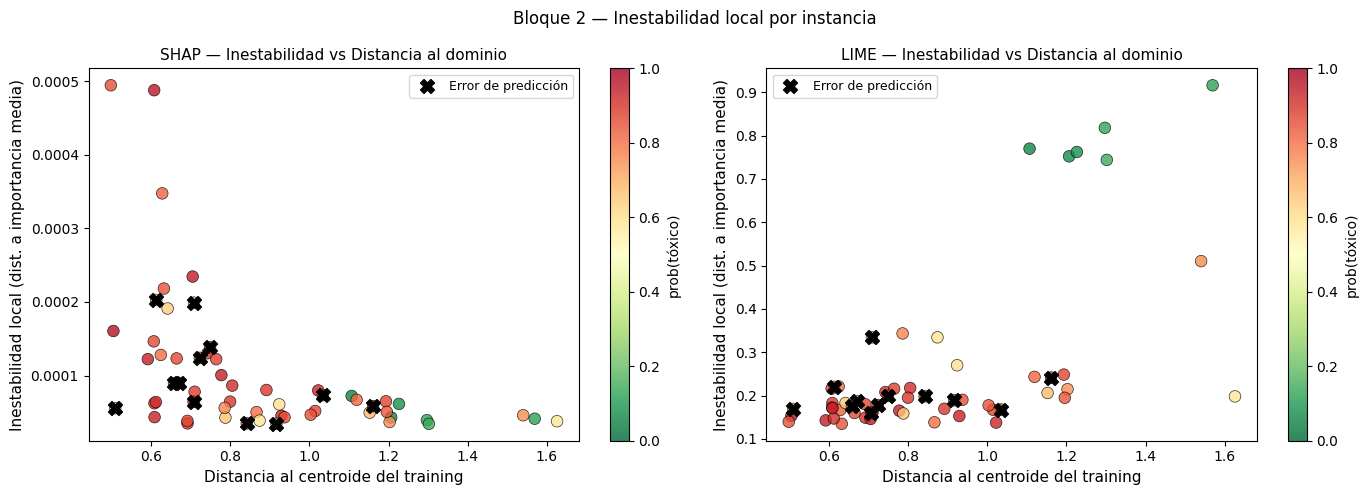

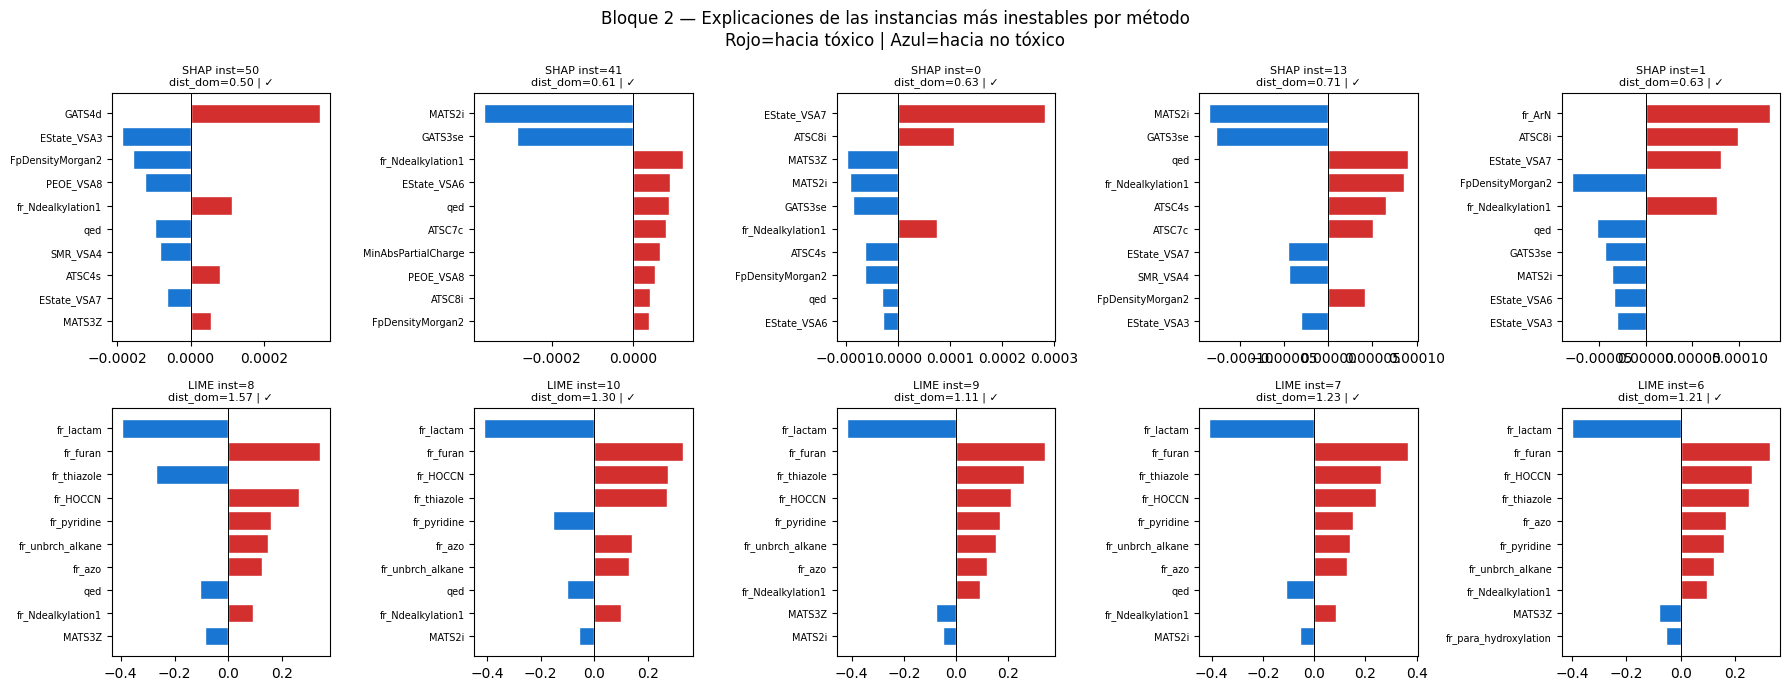

CONJETURA — Bloque 2
  Correlación (distancia al dominio vs inestabilidad):
    SHAP: -0.478  |  LIME: 0.616
  Correlación (error de predicción vs inestabilidad):
    SHAP: -0.024  |  LIME: -0.154

  Instancias lejanas al dominio (Q3=1.03, n=15):
    Inestabilidad SHAP: 0.000  vs cercanas: 0.000
    Inestabilidad LIME: 0.466  vs cercanas: 0.188


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 2 — ¿Dónde falla cada método? Inestabilidad local vs dominio
# ══════════════════════════════════════════════════════════════════════════════
#Celda 3 — Bloque 2: Inestabilidad local y distancia al dominio

# Contribución de cada instancia a la inestabilidad (varianza local)
# Para cada instancia i y método, calculamos cuánto se aleja del promedio
def local_instability(attr_matrix):
    """Distancia L2 de cada instancia a la importancia media."""
    mean_attr = attr_matrix.mean(axis=0)
    return np.linalg.norm(attr_matrix - mean_attr, axis=1)

instab_shap = local_instability(shap_attr)
instab_lime = local_instability(lime_attr)

# Distancia de cada instancia de test al centroide del entrenamiento
centroid_train = X_train.mean(axis=0)
dist_to_domain = np.linalg.norm(X_test - centroid_train, axis=1)

# ── Visualización principal ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (method, instab) in zip(axes, [('SHAP', instab_shap), ('LIME', instab_lime)]):
    sc = ax.scatter(dist_to_domain, instab,
                    c=y_prob, cmap='RdYlGn_r',
                    alpha=0.8, edgecolors='k', linewidths=0.5, s=70,
                    vmin=0, vmax=1)
    # Marcar errores con X
    ax.scatter(dist_to_domain[~correct], instab[~correct],
               marker='X', color='black', s=100, zorder=5, label='Error de predicción')
    plt.colorbar(sc, ax=ax, label='prob(tóxico)')
    ax.set_xlabel('Distancia al centroide del training', fontsize=11)
    ax.set_ylabel('Inestabilidad local (dist. a importancia media)', fontsize=11)
    ax.set_title(f'{method} — Inestabilidad vs Distancia al dominio', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Bloque 2 — Inestabilidad local por instancia', fontsize=12)
plt.tight_layout()
plt.show()

# ── Instancias más inestables de cada método ──────────────────────────────────
TOP_INSTAB = 5
fig, axes = plt.subplots(2, TOP_INSTAB, figsize=(18, 7))
for row, (method, instab, attr) in enumerate([
        ('SHAP', instab_shap, shap_attr),
        ('LIME', instab_lime, lime_attr)]):
    top_inst = np.argsort(instab)[::-1][:TOP_INSTAB]
    for col, i in enumerate(top_inst):
        ax = axes[row, col]
        vals = attr[i]
        idx_s = np.argsort(np.abs(vals))[-10:]
        bar_colors = ['#d32f2f' if v > 0 else '#1976d2' for v in vals[idx_s]]
        ax.barh([feature_names[k] for k in idx_s], vals[idx_s],
                color=bar_colors, edgecolor='white')
        ax.axvline(0, color='k', lw=0.7)
        ax.set_title(
            f"{method} inst={i}\n"
            f"dist_dom={dist_to_domain[i]:.2f} | "
            f"{'✓' if correct[i] else '✗'}",
            fontsize=8)
        ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Bloque 2 — Explicaciones de las instancias más inestables por método\n'
             'Rojo=hacia tóxico | Azul=hacia no tóxico', fontsize=12)
plt.tight_layout()
plt.show()

# ── Correlaciones y conjetura ──────────────────────────────────────────────────
corr_shap = np.corrcoef(dist_to_domain, instab_shap)[0, 1]
corr_lime = np.corrcoef(dist_to_domain, instab_lime)[0, 1]
corr_shap_err = np.corrcoef((~correct).astype(int), instab_shap)[0, 1]
corr_lime_err = np.corrcoef((~correct).astype(int), instab_lime)[0, 1]

print("CONJETURA — Bloque 2")
print(f"  Correlación (distancia al dominio vs inestabilidad):")
print(f"    SHAP: {corr_shap:.3f}  |  LIME: {corr_lime:.3f}")
print(f"  Correlación (error de predicción vs inestabilidad):")
print(f"    SHAP: {corr_shap_err:.3f}  |  LIME: {corr_lime_err:.3f}")
print()
q3 = np.percentile(dist_to_domain, 75)
far_mask = dist_to_domain > q3
print(f"  Instancias lejanas al dominio (Q3={q3:.2f}, n={far_mask.sum()}):")
print(f"    Inestabilidad SHAP: {instab_shap[far_mask].mean():.3f}  "
      f"vs cercanas: {instab_shap[~far_mask].mean():.3f}")
print(f"    Inestabilidad LIME: {instab_lime[far_mask].mean():.3f}  "
      f"vs cercanas: {instab_lime[~far_mask].mean():.3f}")

## Bloque 3 — Análisis de features "conflictivas"
Para cada feature, calcular cuántas veces SHAP y LIME difieren en el signo de la atribución (una dice que empuja hacia tóxico, la otra hacia no tóxico). Mostrar un heatmap instancias × features con los conflictos de signo. Elegir 2-3 features con más conflictos y graficar su distribución de valores en train vs las instancias conflictivas.
La conjetura explorable: los conflictos de signo podrían concentrarse en features con distribución bimodal o con interacciones no lineales fuertes con otras features, donde la linealización local de LIME y la marginalización de SHAP llevan a interpretaciones opuestas.

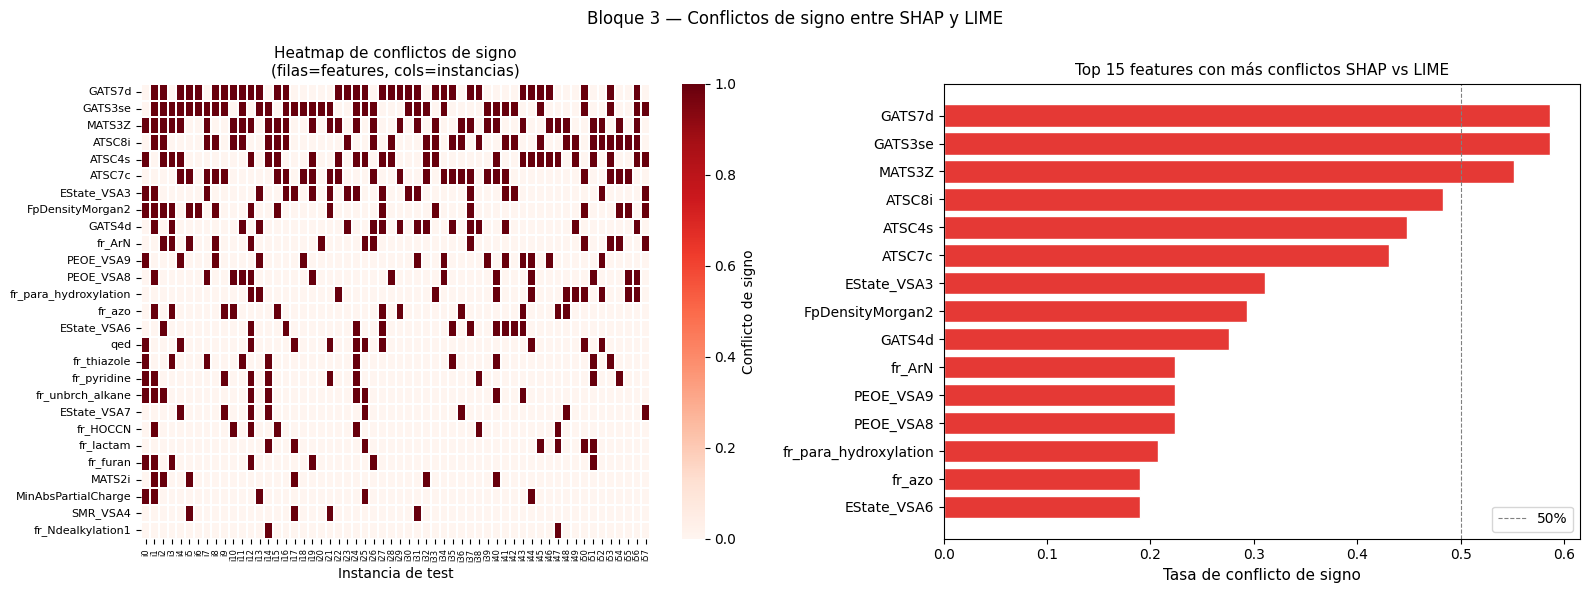

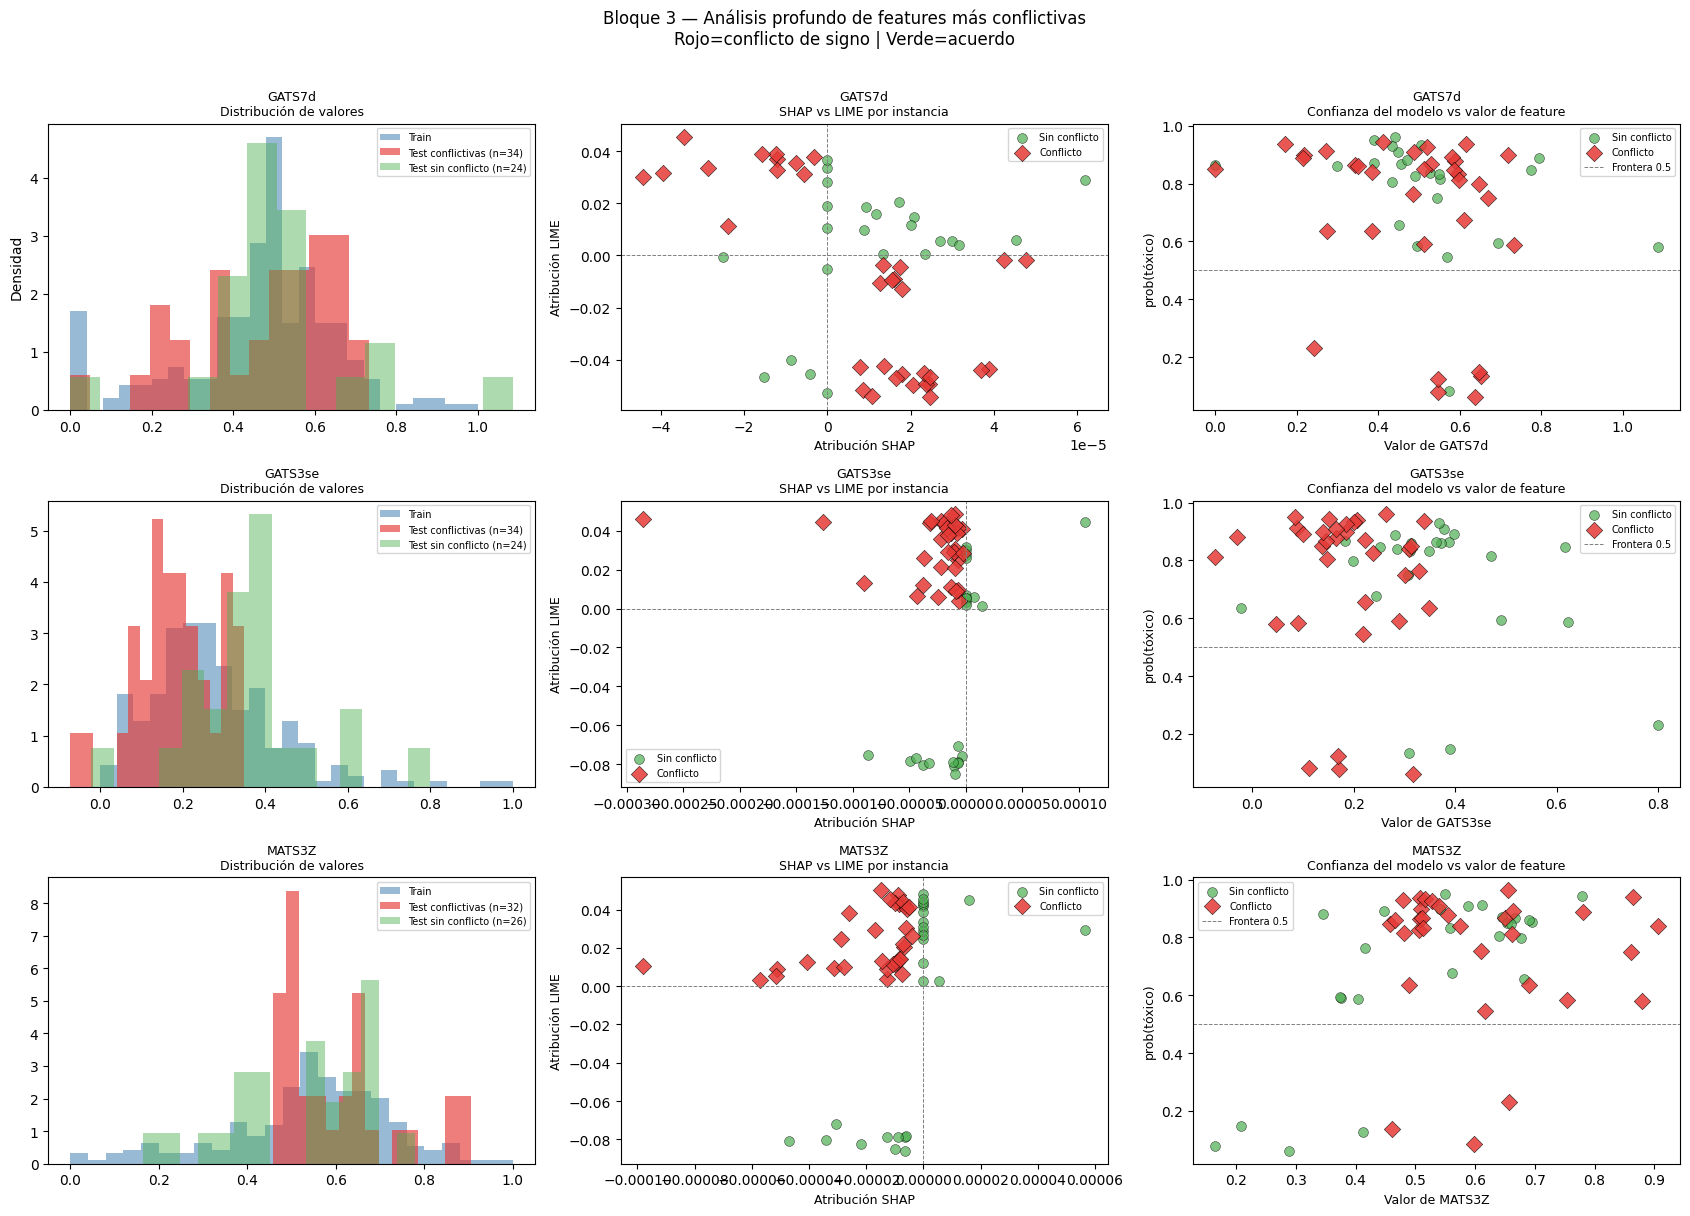

CONJETURA — Bloque 3

  Feature: GATS7d  (conflicto en 34/58 instancias)
    Valor medio train:        0.4616  ±0.1935
    Valor medio conflictivas: 0.4787  ±0.1751
    Desplazamiento (z-score): 0.088
    prob media conflictivas:  0.702  (zona frontera: 4 inst.)

  Feature: GATS3se  (conflicto en 34/58 instancias)
    Valor medio train:        0.2769  ±0.1593
    Valor medio conflictivas: 0.1850  ±0.1003
    Desplazamiento (z-score): 0.577
    prob media conflictivas:  0.736  (zona frontera: 5 inst.)

  Feature: MATS3Z  (conflicto en 32/58 instancias)
    Valor medio train:        0.5411  ±0.1818
    Valor medio conflictivas: 0.6079  ±0.1317
    Desplazamiento (z-score): 0.367
    prob media conflictivas:  0.759  (zona frontera: 5 inst.)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 3 — Features con conflictos de signo entre SHAP y LIME
# ══════════════════════════════════════════════════════════════════════════════
#Celda 4 — Bloque 3: Features con conflictos de signo

# Conflicto de signo: SHAP y LIME tienen signo opuesto (excluyendo ceros)
sign_shap = np.sign(shap_attr)
sign_lime = np.sign(lime_attr)

# Conflicto = signos opuestos y ninguno es cero
conflict_matrix = (sign_shap * sign_lime) < 0   # shape (n_test, n_features)
conflict_rate   = conflict_matrix.mean(axis=0)   # por feature

# ── Heatmap instancias × features ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ordenar features por tasa de conflicto
feat_order = np.argsort(conflict_rate)[::-1]
feat_labels = [feature_names[i] for i in feat_order]

sns.heatmap(conflict_matrix[:, feat_order].T.astype(int),
            ax=axes[0],
            cmap='Reds', cbar_kws={'label': 'Conflicto de signo'},
            xticklabels=[f"i{i}" for i in range(n_test)],
            yticklabels=feat_labels,
            linewidths=0.2)
axes[0].set_title('Heatmap de conflictos de signo\n(filas=features, cols=instancias)',
                  fontsize=11)
axes[0].set_xlabel('Instancia de test')
axes[0].tick_params(axis='y', labelsize=8)
axes[0].tick_params(axis='x', labelsize=6)

# Barplot: tasa de conflicto por feature (top 15)
top15_feat = feat_order[:15]
axes[1].barh([feature_names[i] for i in top15_feat[::-1]],
             conflict_rate[top15_feat[::-1]],
             color='#e53935', edgecolor='white')
axes[1].set_xlabel('Tasa de conflicto de signo', fontsize=11)
axes[1].set_title('Top 15 features con más conflictos SHAP vs LIME', fontsize=11)
axes[1].axvline(0.5, ls='--', color='gray', lw=0.8, label='50%')
axes[1].legend()

plt.suptitle('Bloque 3 — Conflictos de signo entre SHAP y LIME', fontsize=12)
plt.tight_layout()
plt.show()

# ── Análisis profundo: top 3 features conflictivas ────────────────────────────
TOP_FEAT = 3
top_conflict_features = feat_order[:TOP_FEAT]

fig, axes = plt.subplots(TOP_FEAT, 3, figsize=(17, TOP_FEAT * 4))

for row, fi in enumerate(top_conflict_features):
    fname = feature_names[fi]
    conflict_mask = conflict_matrix[:, fi]

    # Col 0: distribución del valor de la feature en train vs instancias conflictivas
    ax = axes[row, 0]
    ax.hist(X_train[:, fi], bins=25, alpha=0.55, color='steelblue',
            density=True, label='Train')
    ax.hist(X_test[conflict_mask, fi], bins=15, alpha=0.65, color='#e53935',
            density=True, label=f'Test conflictivas (n={conflict_mask.sum()})')
    ax.hist(X_test[~conflict_mask, fi], bins=15, alpha=0.45, color='#4caf50',
            density=True, label=f'Test sin conflicto (n={(~conflict_mask).sum()})')
    ax.set_title(f'{fname}\nDistribución de valores', fontsize=9)
    ax.legend(fontsize=7)
    ax.set_ylabel(f'Densidad' if row == 0 else '')

    # Col 1: atribuciones SHAP y LIME para esta feature, coloreadas por conflicto
    ax = axes[row, 1]
    ax.scatter(shap_attr[~conflict_mask, fi], lime_attr[~conflict_mask, fi],
               color='#4caf50', alpha=0.7, s=50, label='Sin conflicto', edgecolors='k', lw=0.4)
    ax.scatter(shap_attr[conflict_mask, fi], lime_attr[conflict_mask, fi],
               color='#e53935', alpha=0.85, s=70, label='Conflicto', edgecolors='k', lw=0.4,
               marker='D')
    ax.axhline(0, color='gray', lw=0.7, ls='--')
    ax.axvline(0, color='gray', lw=0.7, ls='--')
    ax.set_xlabel('Atribución SHAP', fontsize=9)
    ax.set_ylabel('Atribución LIME', fontsize=9)
    ax.set_title(f'{fname}\nSHAP vs LIME por instancia', fontsize=9)
    ax.legend(fontsize=7)

    # Col 2: ¿los conflictos se relacionan con la confianza del modelo?
    ax = axes[row, 2]
    ax.scatter(X_test[~conflict_mask, fi], y_prob[~conflict_mask],
               color='#4caf50', alpha=0.7, s=50, label='Sin conflicto', edgecolors='k', lw=0.4)
    ax.scatter(X_test[conflict_mask, fi], y_prob[conflict_mask],
               color='#e53935', alpha=0.85, s=70, label='Conflicto', edgecolors='k', lw=0.4,
               marker='D')
    ax.axhline(0.5, color='gray', lw=0.7, ls='--', label='Frontera 0.5')
    ax.set_xlabel(f'Valor de {fname}', fontsize=9)
    ax.set_ylabel('prob(tóxico)', fontsize=9)
    ax.set_title(f'{fname}\nConfianza del modelo vs valor de feature', fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Bloque 3 — Análisis profundo de features más conflictivas\n'
             'Rojo=conflicto de signo | Verde=acuerdo', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── Conjetura ─────────────────────────────────────────────────────────────────
print("CONJETURA — Bloque 3")
for fi in top_conflict_features:
    fname = feature_names[fi]
    conflict_mask = conflict_matrix[:, fi]
    vals_conflict  = X_test[conflict_mask, fi]
    vals_no_conflict = X_test[~conflict_mask, fi]
    vals_train = X_train[:, fi]

    # Bimodalidad aproximada: diferencia entre media de train y de conflictivas
    shift = abs(vals_conflict.mean() - vals_train.mean()) / (vals_train.std() + 1e-9)
    print(f"\n  Feature: {fname}  (conflicto en {conflict_mask.sum()}/{n_test} instancias)")
    print(f"    Valor medio train:        {vals_train.mean():.4f}  ±{vals_train.std():.4f}")
    print(f"    Valor medio conflictivas: {vals_conflict.mean():.4f}  ±{vals_conflict.std():.4f}")
    print(f"    Desplazamiento (z-score): {shift:.3f}")
    print(f"    prob media conflictivas:  {y_prob[conflict_mask].mean():.3f}  "
          f"(zona frontera: {((y_prob[conflict_mask] > 0.35) & (y_prob[conflict_mask] < 0.65)).sum()} inst.)")


--
##Gráfico de Ranking de Features

La tabla impresa tiene las 27 features con su importancia media absoluta según SHAP y LIME, su posición en el ranking de cada método, y rank_diff que indica cuántas posiciones sube o baja una feature entre los dos métodos — las diferencias grandes son exactamente los conflictos que analizaste en el Bloque 3.

El bump chart del panel derecho es especialmente útil: cada línea es una feature, y las líneas rojas son las que más cambian de posición entre SHAP y LIME. Son la representación visual directa de las discrepancias más importantes entre los dos explicadores para cada modelo.




  Modelo: SVM — Ranking completo de features
              Feature  SHAP_mean_abs  LIME_mean_abs  SHAP_rank  LIME_rank  rank_diff
    fr_Ndealkylation1       0.000054       0.095771          1          8         -7
               MATS2i       0.000029       0.032814          2         15        -13
              GATS3se       0.000025       0.037312          3         12         -9
     FpDensityMorgan2       0.000023       0.033569          4         14        -10
               ATSC4s       0.000023       0.017913          5         24        -19
          EState_VSA7       0.000022       0.026083          6         19        -13
               GATS4d       0.000021       0.026720          7         18        -11
                  qed       0.000020       0.050897          8          9         -1
               GATS7d       0.000019       0.027327          9         17         -8
          EState_VSA3       0.000017       0.028586         10         16         -6
               ATSC

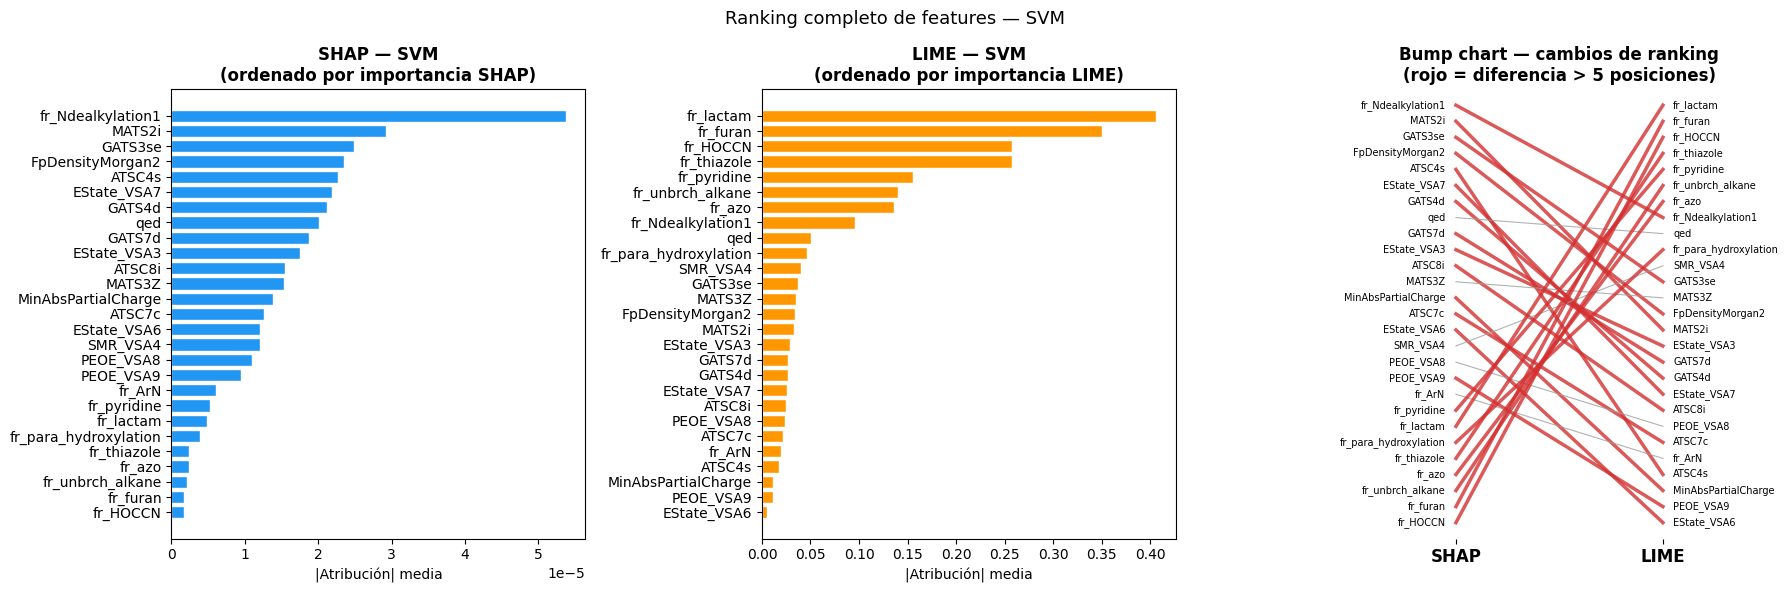


  Modelo: NB — Ranking completo de features
              Feature  SHAP_mean_abs  LIME_mean_abs  SHAP_rank  LIME_rank  rank_diff
            fr_lactam       0.145075       0.930204          1          1          0
             fr_furan       0.027778       0.852679          2          2          0
             fr_HOCCN       0.023732       0.826947          3          4         -1
          fr_thiazole       0.017291       0.845777          4          3          1
     fr_unbrch_alkane       0.009520       0.595446          5          6         -1
               fr_azo       0.007946       0.825373          6          5          1
          fr_pyridine       0.000915       0.005922          7          7          0
               ATSC4s       0.000458       0.002236          8         27        -19
             SMR_VSA4       0.000320       0.002813          9         18         -9
            PEOE_VSA8       0.000167       0.003170         10         12         -2
fr_para_hydroxylatio

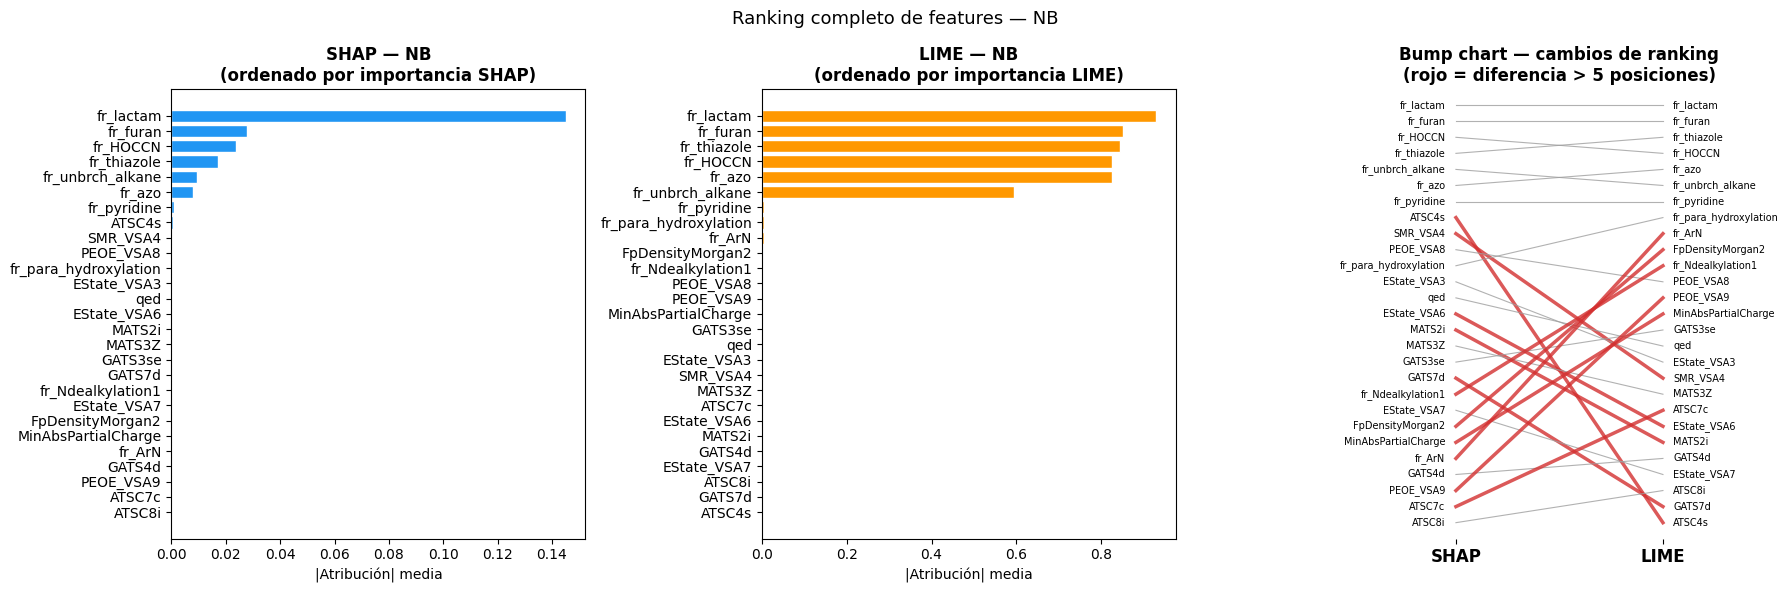


  Modelo: KNN — Ranking completo de features
              Feature  SHAP_mean_abs  LIME_mean_abs  SHAP_rank  LIME_rank  rank_diff
            fr_lactam       0.042894       0.467534          1          1          0
               MATS2i       0.041747       0.016160          2         19        -17
               fr_ArN       0.035996       0.045405          3         10         -7
               GATS4d       0.029585       0.008413          4         25        -21
fr_para_hydroxylation       0.028837       0.019035          5         17        -12
               ATSC4s       0.028026       0.016827          6         18        -12
     FpDensityMorgan2       0.027395       0.040052          7         11         -4
             SMR_VSA4       0.023932       0.033073          8         13         -5
          EState_VSA3       0.023388       0.038184          9         12         -3
               ATSC8i       0.020471       0.011203         10         24        -14
               MATS

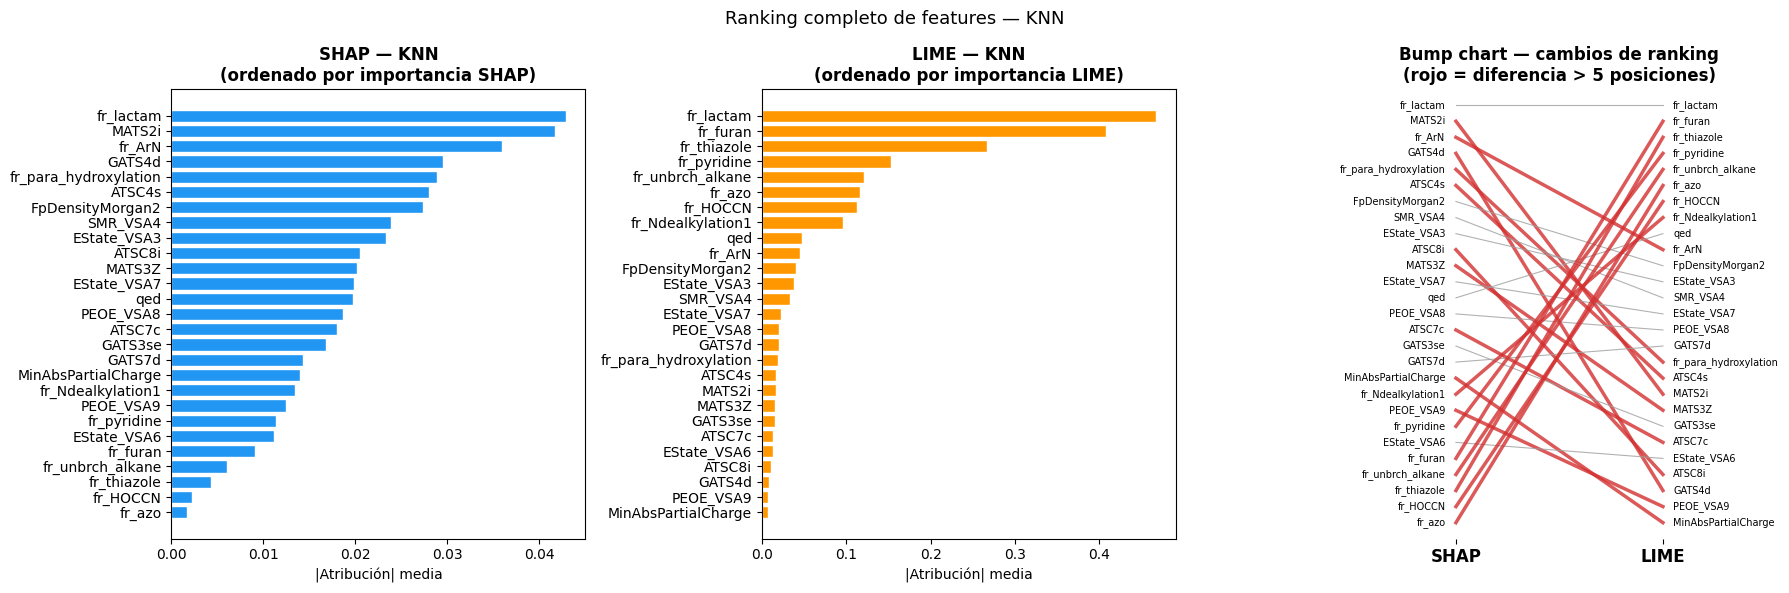

In [ ]:
# ── Ranking completo de features por método ───────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

for name in selected_names:
    shap_a = shap_attributions[name]
    lime_a = lime_attributions[name]
    if shap_a.ndim == 3:
        shap_a = shap_a[:, :, 1]

    # Importancia media absoluta por feature
    shap_importance = np.abs(shap_a).mean(axis=0)
    lime_importance = np.abs(lime_a).mean(axis=0)

    ranking = pd.DataFrame({
        'Feature':         feature_names,
        'SHAP_mean_abs':   shap_importance,
        'LIME_mean_abs':   lime_importance,
        'SHAP_rank':       pd.Series(shap_importance).rank(ascending=False).astype(int).values,
        'LIME_rank':       pd.Series(lime_importance).rank(ascending=False).astype(int).values,
    }).sort_values('SHAP_rank')

    ranking['rank_diff'] = ranking['SHAP_rank'] - ranking['LIME_rank']

    print(f"\n{'='*65}")
    print(f"  Modelo: {name} — Ranking completo de features")
    print(f"{'='*65}")
    print(ranking.to_string(index=False))

    # ── Visualización comparativa de rankings ─────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Barplot SHAP
    shap_sorted = ranking.sort_values('SHAP_mean_abs', ascending=True)
    axes[0].barh(shap_sorted['Feature'], shap_sorted['SHAP_mean_abs'],
                 color='#2196F3', edgecolor='white')
    axes[0].set_title(f'SHAP — {name}\n(ordenado por importancia SHAP)', fontweight='bold')
    axes[0].set_xlabel('|Atribución| media')

    # Barplot LIME
    lime_sorted = ranking.sort_values('LIME_mean_abs', ascending=True)
    axes[1].barh(lime_sorted['Feature'], lime_sorted['LIME_mean_abs'],
                 color='#FF9800', edgecolor='white')
    axes[1].set_title(f'LIME — {name}\n(ordenado por importancia LIME)', fontweight='bold')
    axes[1].set_xlabel('|Atribución| media')

    # Bump chart: evolución del ranking entre métodos
    ax = axes[2]
    for _, row in ranking.iterrows():
        color = '#d32f2f' if abs(row['rank_diff']) > 5 else '#9e9e9e'
        lw    = 2.5 if abs(row['rank_diff']) > 5 else 0.8
        ax.plot([0, 1],
                [row['SHAP_rank'], row['LIME_rank']],
                color=color, lw=lw, alpha=0.8)
        ax.text(-0.05, row['SHAP_rank'], row['Feature'],
                ha='right', va='center', fontsize=7)
        ax.text(1.05, row['LIME_rank'], row['Feature'],
                ha='left', va='center', fontsize=7)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(len(feature_names) + 1, 0)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['SHAP', 'LIME'], fontsize=12, fontweight='bold')
    ax.set_ylabel('Ranking (1 = más importante)')
    ax.set_title(f'Bump chart — cambios de ranking\n(rojo = diferencia > 5 posiciones)',
                 fontweight='bold')
    ax.yaxis.set_visible(False)
    ax.spines[['left','right','top','bottom']].set_visible(False)

    plt.suptitle(f'Ranking completo de features — {name}', fontsize=13)
    plt.tight_layout()
    plt.show()

In [ ]:
# ── Exportar de valores de las 27 feature attributions ───────────────
import os
import pandas as pd
import numpy as np

os.makedirs('results', exist_ok=True)

# Crear DataFrame base con los nombres de las features
attr_df = pd.DataFrame({'Feature': feature_names})

for name in selected_names:
    # 1. Procesar SHAP
    shap_vals = shap_attributions[name]
    if shap_vals.ndim == 3:
        shap_vals = shap_vals[:, :, 1]  # clase positiva
    attr_df[f'{name}_SHAP'] = np.abs(shap_vals).mean(axis=0)

    # 2. Procesar LIME
    lime_vals = lime_attributions[name]
    attr_df[f'{name}_LIME'] = np.abs(lime_vals).mean(axis=0)

# Exportar a CSV
export_path = os.path.join('results', 'feature_attributions.csv')
attr_df.to_csv(export_path, index=False, sep=';')
print(f'\u2705 Valores de Atribucion (Media Absoluta) exportados a: {export_path}')
print(attr_df.head(27))


✅ Valores de Atribucion (Media Absoluta) exportados a: results/feature_attributions.csv
                  Feature  SVM_SHAP  SVM_LIME   NB_SHAP   NB_LIME  KNN_SHAP  \
0                SMR_VSA4  0.000012  0.040054  0.000320  0.002813  0.023932   
1             fr_pyridine  0.000005  0.155377  0.000915  0.005922  0.011420   
2               fr_lactam  0.000005  0.406121  0.145075  0.930204  0.042894   
3             EState_VSA6  0.000012  0.004944  0.000099  0.002751  0.011194   
4             EState_VSA7  0.000022  0.026083  0.000050  0.002579  0.019841   
5                 GATS3se  0.000025  0.037312  0.000074  0.002920  0.016826   
6             fr_thiazole  0.000002  0.257344  0.017291  0.845777  0.004315   
7               PEOE_VSA9  0.000009  0.010868  0.000021  0.003136  0.012423   
8                  fr_azo  0.000002  0.136462  0.007946  0.825373  0.001711   
9                fr_HOCCN  0.000002  0.257643  0.023732  0.826947  0.002278   
10      fr_Ndealkylation1  0.000054  0.0957

In [ ]:
# ── Porcentaje de coincidencia Top 15 (SHAP vs LIME) por modelo ──
top_k = 15
print(f"\n--- Coincidencia Top {top_k} features (SHAP vs LIME) ---")
overlap_results = {}

for name in selected_names:
    if f'{name}_SHAP' in attr_df.columns and f'{name}_LIME' in attr_df.columns:
        # Obtener los top K features para SHAP y LIME
        top_shap = set(attr_df.nlargest(top_k, f'{name}_SHAP')['Feature'])
        top_lime = set(attr_df.nlargest(top_k, f'{name}_LIME')['Feature'])

        # Calcular intersección
        intersection = top_shap.intersection(top_lime)
        overlap_pct = (len(intersection) / top_k) * 100
        overlap_results[name] = overlap_pct

        print(f'\u2705 Modelo {name}: {overlap_pct:.2f}% de coincidencia ({len(intersection)}/{top_k} features)')
        print(f'   Features en común: {", ".join(intersection)}\n')



--- Coincidencia Top 15 features (SHAP vs LIME) ---
✅ Modelo SVM: 40.00% de coincidencia (6/15 features)
   Features en común: GATS3se, MATS3Z, FpDensityMorgan2, qed, MATS2i, fr_Ndealkylation1

✅ Modelo NB: 60.00% de coincidencia (9/15 features)
   Features en común: fr_pyridine, fr_azo, PEOE_VSA8, fr_para_hydroxylation, fr_furan, fr_unbrch_alkane, fr_thiazole, fr_lactam, fr_HOCCN

✅ Modelo KNN: 53.33% de coincidencia (8/15 features)
   Features en común: EState_VSA3, PEOE_VSA8, SMR_VSA4, fr_ArN, FpDensityMorgan2, qed, EState_VSA7, fr_lactam

